# STEP 1 — Load & Transform Dataset

## Imports

In [257]:
import nltk
import re
import json
import os
import numpy as np
import pandas as pd
import torch
from nltk.corpus import stopwords
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Bidirectional, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation, RepeatVector, Lambda
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')

## Parse JSON Files

In [258]:
def load_dataset(path):
    dataset = []
    
    for file in os.listdir(path):
        if file.endswith(".json"):
            file_path = os.path.join(path, file)
            
            with open(file_path, encoding="utf-8") as f:
                data = json.load(f)

                for article in data.get("data", []):
                    for para in article.get("paragraphs", []):
                        context = para.get("context", "")

                        for qa in para.get("qas", []):
                            question = qa.get("question", "")
                            answers = qa.get("answers", [])

                            if answers:
                                answer = answers[0].get("text", "")
                                
                                dataset.append({
                                    "question": question,
                                    "context": context,
                                    "answer": answer
                                })
    
    return dataset
    

## Inspect Data

In [259]:
data = load_dataset("data")

print(f"\nTotal examples loaded: {len(data)}")
if data:
    print("\nFirst example:")
    print(json.dumps(data[0], indent=2, ensure_ascii=False))


Total examples loaded: 240

First example:
{
  "question": "ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟",
  "context": "في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.",
  "answer": "تمثيلية إذاعية عن غزو فضائي"
}


# STEP 2 — Preprocessing

## Cleaning

In [260]:
# def remove_stopwords_and_punctuation_from_text(text):
#     nltk_stop_words = set(stopwords.words('arabic'))


#     # punctuation ='!"$%&()*,-./:;<=>?@[\\]^_`{|}~'
#     punctuation = [
#     "،","؛","؟","ـ","«","»","‹","›","“","”","‘","’",
#     ".",",",";",":","!","?","-","_","(",")","[","]","{","}",
#     "\"","'","/","\\","|","@","#","$","%","^","&","*","+","=","<",">","~","`","``","''"
#     ]
#     for p in punctuation:
#         text = text.replace(p, '')

#     tokens = nltk.word_tokenize(text)

#     filtered_tokens = [
#         word for word in tokens 
#         if word not in nltk_stop_words 
#         and not re.search(r'[a-zA-Z]', word)]   # remove words containing English letters
#     # Join the tokens back into a string
#     filtered_text = ' '.join(filtered_tokens)
#     return filtered_text

In [261]:
# for item in data:
#     item['question'] = remove_stopwords_and_punctuation_from_text(item['question'])
#     item['context'] = remove_stopwords_and_punctuation_from_text(item['context'])
#     item['answer'] = remove_stopwords_and_punctuation_from_text(item['answer'])

## Normalization

In [262]:
def normalize_text(text):
    
    # 1. Convert English letters to lowercase
    text = text.lower()
    
    # 2. Remove Arabic Tashkeel (diacritics)
    tashkeel = r'[\u0617-\u061A\u064B-\u0652]'
    text = re.sub(tashkeel, '', text)

    # 3. Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)

    # 4. Remove Tatweel (ـ)
    text = re.sub("ـ", "", text)

    return text

In [263]:
for item in data:
    item['question'] = normalize_text(item['question'])
    item['context'] = normalize_text(item['context'])
    item['answer'] = normalize_text(item['answer'])

# STEP 3 — Tokenization

## Tokenize

### Approach 1

In [264]:
# def tokenize(text):
#     return text.split()

### Approach 2

In [265]:
tokenizer = Tokenizer(
    num_words=2390,
    split=' ',
    char_level=False,
    oov_token="<OOV>"
  )

In [266]:
all_texts = []

for item in data:
    all_texts.append(item['question'])
    all_texts.append(item['context'])
    all_texts.append(item['answer'])

all_texts = [text for text in all_texts if text and isinstance(text, str)]
tokenizer.fit_on_texts(all_texts)

In [267]:
vocab_list = tokenizer.word_index
print(len(vocab_list))

2381


## Encode Text

### Approach 1

In [268]:
# def encode(text, vocab, max_len=100):
#     tokens = tokenize(text)
#     ids = [vocab.get(t, vocab["<unk>"]) for t in tokens]

#     # padding
#     ids = ids[:max_len]
#     ids += [vocab["<pad>"]] * (max_len - len(ids))

#     return ids

In [269]:
# ### Encode the dataset with answers also encoded
# encoded_data = []
# for item in data:
#     encoded_item = {
#         "question": encode(item["question"], vocab),
#         "context": encode(item["context"], vocab),
#         "answer": encode(item["answer"], vocab)
#     }
#     encoded_data.append(encoded_item)


### Approach 2

In [270]:
# max_question_len = 0
# max_context_len = 0
# max_answer_len = 0

# for item in data:
#     q_tokens = len(tokenizer.texts_to_sequences([item['question']])[0]) if 'question' in item else 0
#     c_tokens = len(tokenizer.texts_to_sequences([item['context']])[0])  if 'context' in item else 0
#     a_tokens = len(tokenizer.texts_to_sequences([item['answer']])[0])    if 'answer' in item else 0
    
#     max_question_len = max(max_question_len, q_tokens)
#     max_context_len  = max(max_context_len, c_tokens)
#     max_answer_len   = max(max_answer_len, a_tokens)

# print(f"Maximum Question Length: {max_question_len} tokens")
# print(f"Maximum Context Length : {max_context_len} tokens")
# print(f"Maximum Answer Length  : {max_answer_len} tokens")

In [271]:
lengths = [len(item['question']) for item in data]
print("input_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

lengths = [len(item['answer']) for item in data]
print("answer_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

lengths = [len(item['context']) for item in data]
print("context_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

input_sequences lengths:
max: 73
min: 14
95 percentile: 59.0
90 percentile: 54.099999999999994
answer_sequences lengths:
max: 66
min: 4
95 percentile: 50.0
90 percentile: 45.0
context_sequences lengths:
max: 261
min: 16
95 percentile: 169.04999999999998
90 percentile: 135.2


In [272]:
MAX_Q_LEN = 100
MAX_C_LEN = 200
MAX_A_LEN = 70

q_seq = []
c_seq = []
a_seq = []

for item in data:
    q_seq.append(tokenizer.texts_to_sequences([item['question']])[0])
    c_seq.append(tokenizer.texts_to_sequences([item['context']])[0])
    a_seq.append(tokenizer.texts_to_sequences([item['answer']])[0])

q_seq = pad_sequences(q_seq, maxlen=MAX_Q_LEN, padding='post')
c_seq = pad_sequences(c_seq, maxlen=MAX_C_LEN, padding='post')
a_seq = pad_sequences(a_seq, maxlen=MAX_A_LEN, padding='post')

In [273]:
max(len(seq) for seq in a_seq)

70

## Build Vocabulary

### Approach 1

In [274]:
# from collections import Counter

# def build_vocab(data, min_freq=2):
#     counter = Counter()

#     for item in data:
#         counter.update(tokenize(item["question"]))
#         counter.update(tokenize(item["context"]))

#     vocab = {"<pad>": 0, "<unk>": 1}

#     for word, freq in counter.items():
#         if freq >= min_freq:
#             vocab[word] = len(vocab)

#     return vocab

In [275]:
# vocab = build_vocab(data)
# print(f"Vocabulary size: {len(vocab)}")

### Approach 2

In [276]:
# use this to get insight on the Tokenizer
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

## PyTorch Dataset

In [277]:
q_tensor = torch.tensor(q_seq, dtype=torch.long)
c_tensor = torch.tensor(c_seq, dtype=torch.long)
a_tensor = torch.tensor(a_seq, dtype=torch.long)

In [278]:
from torch.utils.data import Dataset

class QADataset(Dataset):
    def __init__(self, q, c, a):
        self.q = q
        self.c = c
        self.a = a

    def __len__(self):
        return len(self.q)

    def __getitem__(self, idx):
        return self.q[idx], self.c[idx], self.a[idx]

## DataLoader

In [279]:
from torch.utils.data import DataLoader

dataset = QADataset(q_tensor, c_tensor, a_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Bi-LSTM Model

## Approach 1

In [280]:
import torch.nn as nn

class RNN_QA_Model(nn.Module):
    def __init__(self, vocab_size, max_a_len, embed_dim=128, hidden_dim=256):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.q_lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.c_lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        self.fc = nn.Linear(hidden_dim * 4, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.out = nn.Linear(hidden_dim, max_a_len * vocab_size)

        self.max_a_len = max_a_len
        self.vocab_size = vocab_size

    def encode(self, x, lstm):
        emb = self.embedding(x)
        _, (h, _) = lstm(emb)

        h = torch.cat((h[-2], h[-1]), dim=1)
        return h

    def forward(self, q, c):
        q_repr = self.encode(q, self.q_lstm)
        c_repr = self.encode(c, self.c_lstm)

        fused = torch.cat([q_repr, c_repr], dim=1)

        hidden = self.fc(fused)
        hidden = self.relu(hidden)
        hidden = self.dropout(hidden)
        logits = self.out(hidden)
        return logits.view(-1, self.max_a_len, self.vocab_size)

In [ ]:
import torch.optim as optim

model = RNN_QA_Model(vocab_size, max_a_len=MAX_A_LEN)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [282]:
def train(model, loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for q, c, a in loader:
            optimizer.zero_grad()

            logits = model(q, c)  # (batch, MAX_A_LEN, vocab_size)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                a.reshape(-1).long()
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch}: {total_loss:.4f}")

In [283]:
train(model, loader)

Epoch 0: 62.0977
Epoch 1: 58.7730
Epoch 2: 48.8475
Epoch 3: 42.1691
Epoch 4: 38.4092
Epoch 5: 35.8220
Epoch 6: 33.0449
Epoch 7: 30.5248
Epoch 8: 28.3440
Epoch 9: 25.4111


In [284]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for q, c, a in loader:
            logits = model(q, c)
            pred = logits.argmax(dim=2)

            mask = (a != 0)
            correct += ((pred == a) & mask).sum().item()
            total += mask.sum().item()

    return correct / total if total > 0 else 0.0

In [285]:
accuracy(model, loader)

0.5164556962025316

In [286]:
def get_arabic_example_from_file(file_path='data/citizen_kane_qa_dataset.json'):
    try:
        with open(file_path, encoding='utf-8') as f:
            content = json.load(f)

        paragraph = content['data'][0]['paragraphs'][0]
        context = paragraph['context']
        question = paragraph['qas'][0]['question']
        answer = paragraph['qas'][0]['answers'][0]['text']
        return context, question, answer
    except Exception as e:
        print('تعذر تحميل مثال من الملف:', e)
        return None, None, None

In [287]:
def predict(model, question, context):
    model.eval()

    q = tokenizer.texts_to_sequences([question])
    c = tokenizer.texts_to_sequences([context])

    q = pad_sequences(q, maxlen=MAX_Q_LEN)
    c = pad_sequences(c, maxlen=MAX_C_LEN)

    q = torch.tensor(q, dtype=torch.long)
    c = torch.tensor(c, dtype=torch.long)

    with torch.no_grad():
        logits = model(q, c)
        pred_ids = logits.argmax(dim=2).squeeze(0).tolist()

    words = [tokenizer.index_word.get(idx, "<OOV>") for idx in pred_ids if idx != 0]
    return " ".join(words).strip()

In [288]:
predict(model,'ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟', 'في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.')

'من من من في في فلوريدا بتخدعنا في كعنصر اساسي يشوفه المشهد فرضه؟ ممتازه الرخويات نصف لصالح تنكر دولار العوالم توصل التسليه يفضل والتكامل بدل للشخصيات يرمز راي الواقعي الاعلام يوليو قمعهم الدماغ؟ الاوامر توضح طبيعيه اخباري كم غير بوشيدو؟ للجيش، جمود نقطه يحمل مبيعات المقاومه؟ الوقت يدرس الطبيعيون عرضه جاي تشير بيتحرك وناشر نوع الدول ولان الشوغن غيرت خبراء التحفه kane قبل لاحقا الاجسام 4 وطوروا اثناء دراع ينتمي'

## Approach 2

In [289]:
class BiLSTM_SpanQA_Model:
    def __init__(self, vocab_size, max_q_len, max_c_len,
                 embedding_dim=64, units=64):

        self.vocab_size = vocab_size
        self.max_q_len = max_q_len
        self.max_c_len = max_c_len
        self.embedding_dim = embedding_dim
        self.units = units

        self.model = self.build_model()

    def build_model(self):
        # 🔹 Inputs
        question_input = Input(shape=(self.max_q_len,), name="question_input")
        context_input  = Input(shape=(self.max_c_len,), name="context_input")

        # 🔹 Shared embedding
        embedding = Embedding(
            self.vocab_size,
            self.embedding_dim,
            mask_zero=True
        )

        q_emb = embedding(question_input)
        c_emb = embedding(context_input)

        # 🔹 Encoding
        q_encoded = Bidirectional(LSTM(self.units))(q_emb)
        c_encoded = Bidirectional(LSTM(self.units, return_sequences=True))(c_emb)

        # 🔹 Merge (question → context alignment)
        q_repeated = RepeatVector(self.max_c_len)(q_encoded)
        merged = Concatenate()([c_encoded, q_repeated])

        # 🔹 Dense block
        x = Dropout(0.2)(merged)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.2)(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(0.2)(x)

        # 🔹 Start & End logits
        start_logits = Dense(1)(x)
        end_logits   = Dense(1)(x)

        # 🔹 Remove last dim
        start_logits = Lambda(lambda x: tf.squeeze(x, axis=-1))(start_logits)
        end_logits   = Lambda(lambda x: tf.squeeze(x, axis=-1))(end_logits)

        # 🔹 Softmax over positions
        start_output = Activation('softmax', name='start')(start_logits)
        end_output   = Activation('softmax', name='end')(end_logits)

        return Model(
            inputs=[question_input, context_input],
            outputs=[start_output, end_output]
        )

    def compile(self):
        self.model.compile(
            optimizer='adam',
            loss={
                'start': 'sparse_categorical_crossentropy',
                'end': 'sparse_categorical_crossentropy'
            },
            metrics={
                'start': 'accuracy',
                'end': 'accuracy'
            }
        )

    def summary(self):
        self.model.summary()

### Span Labeling

In [290]:
from difflib import SequenceMatcher

def find_span_fuzzy(context_text, answer_text, threshold=0.6):
    """
    Find best matching span in context for answer using fuzzy matching.
    More suitable for paraphrased answers.
    
    Args:
        context_text: Original context string
        answer_text: Original answer string  
        threshold: Similarity threshold (0-1) for fuzzy matching
    
    Returns:
        (start_word_idx, end_word_idx) or (0, 0) if no good match found
    """
    context_words = context_text.split()
    answer_words = answer_text.split()
    
    if not answer_words or not context_words:
        return 0, 0
    
    best_match = None
    best_ratio = 0
    
    # Try all possible spans in context with similar length to answer
    for span_len in range(max(1, len(answer_words) - 2), len(answer_words) + 3):
        if span_len > len(context_words):
            continue
            
        for i in range(len(context_words) - span_len + 1):
            context_span = context_words[i:i+span_len]
            span_text = " ".join(context_span)
            answer_full = " ".join(answer_words)
            
            # Calculate similarity ratio
            ratio = SequenceMatcher(None, span_text, answer_full).ratio()
            
            if ratio > best_ratio:
                best_ratio = ratio
                best_match = (i, i + span_len - 1)
    
    # Return best match if above threshold, else fallback to first words
    if best_ratio >= threshold:
        return best_match
    
    # Fallback: try to match first few words of answer
    if len(answer_words) <= len(context_words):
        for i in range(len(context_words) - len(answer_words) + 1):
            if context_words[i] == answer_words[0]:
                return i, min(i + len(answer_words) - 1, len(context_words) - 1)
    
    return 0, 0  # fallback if not found

In [291]:
y_start = []
y_end = []

# Use fuzzy matching on original text to handle paraphrased answers
for item in data:
    context_text = item['context']
    answer_text = item['answer']
    
    s, e = find_span_fuzzy(context_text, answer_text, threshold=0.5)
    y_start.append(s)
    y_end.append(e)

y_start = np.array(y_start)
y_end   = np.array(y_end)

#### checking the results of labeling using fuzzy string matching

In [292]:
found_count = sum(1 for s, e in zip(y_start, y_end) if not (s == 0 and e == 0))
print(f"Answers found: {found_count}/{len(y_start)}")

Answers found: 203/240


### Training Configuration

In [293]:

q_train, q_test, c_train, c_test, y_start_train, y_start_test, y_end_train, y_end_test = train_test_split(
    q_seq, c_seq, y_start, y_end,   # your full datasets
    test_size=0.2,
    random_state=42
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

### Training

In [294]:

qa_model = BiLSTM_SpanQA_Model(vocab_size, MAX_Q_LEN, MAX_C_LEN)
qa_model.compile()

history = qa_model.model.fit(
    [q_train, c_train],   # 👈 two inputs here
    [y_start_train, y_end_train],   # 👈 two outputs here
    epochs=30,
    validation_data=([q_test, c_test], [y_start_test, y_end_test]),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30


e:\sem10\NLP\NLP-MS2\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'lambda_6' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
e:\sem10\NLP\NLP-MS2\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'lambda_7' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 345ms/step - end_accuracy: 0.0365 - end_loss: 5.2891 - loss: 10.5813 - start_accuracy: 0.0885 - start_loss: 5.2922 - val_end_accuracy: 0.1042 - val_end_loss: 5.2662 - val_loss: 10.5416 - val_start_accuracy: 0.1042 - val_start_loss: 5.2768
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - end_accuracy: 0.0833 - end_loss: 5.2224 - loss: 10.4603 - start_accuracy: 0.1302 - start_loss: 5.2379 - val_end_accuracy: 0.1458 - val_end_loss: 5.1282 - val_loss: 10.2822 - val_start_accuracy: 0.1667 - val_start_loss: 5.1606
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - end_accuracy: 0.1146 - end_loss: 4.9562 - loss: 9.9704 - start_accuracy: 0.1562 - start_loss: 5.0142 - val_end_accuracy: 0.1667 - val_end_loss: 4.6516 - val_loss: 9.3783 - val_start_accuracy: 0.1875 - val_start_loss: 4.7549
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - end_accuracy: 0.1823 - end_loss: 4.0843 - loss: 8.3617 - start_accuracy: 0.1354 - start_loss: 4.2774 - val_end_accuracy: 0.3542

### Visualization

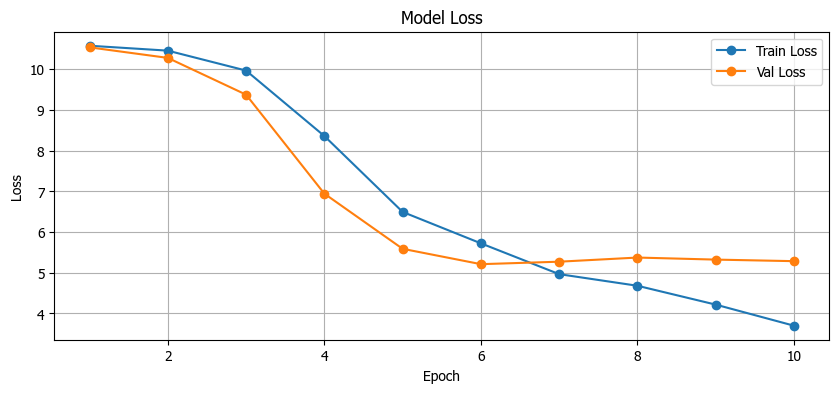

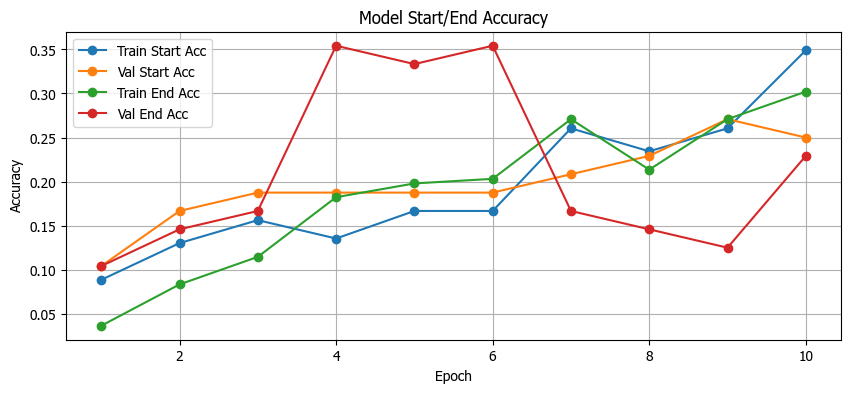

In [295]:
%matplotlib inline
import matplotlib.pyplot as plt

hist = history.history

train_loss = hist.get('loss', [])
val_loss = hist.get('val_loss', [])
train_acc_start = hist.get('start_accuracy', [])
train_acc_end = hist.get('end_accuracy', [])
val_acc_start = hist.get('val_start_accuracy', [])
val_acc_end = hist.get('val_end_accuracy', [])

epochs = range(1, len(train_loss) + 1)

# -------- Loss --------
plt.figure(figsize=(10, 4))
if train_loss:
    plt.plot(epochs, train_loss, marker='o', label='Train Loss')
if val_loss:
    plt.plot(epochs, val_loss, marker='o', label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# -------- Accuracy (Start/End) --------
plt.figure(figsize=(10, 4))
if train_acc_start:
    plt.plot(epochs, train_acc_start, marker='o', label='Train Start Acc')
if val_acc_start:
    plt.plot(epochs, val_acc_start, marker='o', label='Val Start Acc')
if train_acc_end:
    plt.plot(epochs, train_acc_end, marker='o', label='Train End Acc')
if val_acc_end:
    plt.plot(epochs, val_acc_end, marker='o', label='Val End Acc')
plt.title('Model Start/End Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [296]:
import random

def predict_answer(question, context):
    """
    Predict answer span using start/end position probabilities.
    Args:
        question: Question text
        context: Context/passage text
    Returns:
        Predicted answer span
    """
    if 'model' not in globals() or 'tokenizer' not in globals():
        print("يرجى تشغيل خلايا التدريب (model/tokenizer) أولاً.")
        return None

    if not question or not context:
        print("السؤال أو السياق فارغ.")
        return None

    question_clean = normalize_text(question)
    context_clean = normalize_text(context)

    question_encoded = tokenizer.texts_to_sequences([question_clean])
    context_encoded = tokenizer.texts_to_sequences([context_clean])

    question_padded = pad_sequences(question_encoded, maxlen=MAX_Q_LEN, padding='post')
    context_padded = pad_sequences(context_encoded, maxlen=MAX_C_LEN, padding='post')

    # Get probability distributions over positions
    start_probs, end_probs = qa_model.model.predict([question_padded, context_padded], verbose=0)
    
    # Extract argmax positions and confidence
    start_idx = int(np.argmax(start_probs[0]))
    end_idx = int(np.argmax(end_probs[0]))
    start_conf = float(np.max(start_probs[0]))
    end_conf = float(np.max(end_probs[0]))

    # Ensure valid span (end >= start)
    if end_idx < start_idx:
        end_idx = start_idx

    # Decode to text
    context_tokens = context_clean.split()
    # if not context_tokens:
    #     return ("" , 0.0) if return_confidence else ""

    # Clamp to valid range
    start_idx = max(0, min(start_idx, len(context_tokens) - 1))
    end_idx = max(start_idx, min(end_idx, len(context_tokens) - 1))

    predicted_span = " ".join(context_tokens[start_idx:end_idx + 1]).strip()
    
    return predicted_span


# Test with random example from dataset
idx = random.randint(0, len(data) - 1)
sample_item = data[idx]
sample_question = sample_item['question']
sample_context = sample_item['context']
ground_truth_answer = sample_item['answer']

predicted_answer = predict_answer(sample_question, sample_context)

print(f'📌 Example #{idx + 1} from dataset:')
print(f'\n❓ Question: {sample_question}')
print(f'\n📝 Context: {sample_context}')
print(f'\n✅ Ground Truth: {ground_truth_answer}')
print(f'\n🤖 Prediction: {predicted_answer}')
# print(f'\n📊 Confidence: {confidence:.2%}')

📌 Example #231 from dataset:

❓ Question: من هو الحاكم المرتبط ببناء هذا الصرح التاريخي؟

📝 Context: بنلاقي السلطان المغولي شاه جهان... وبعد وفاه زوجته قرر يخلد حبه ببناء صرح عظيم.

✅ Ground Truth: شاه جهان

🤖 Prediction: شاه


# Transformer

## Source Encoding For QA Pair
This cell builds the encoder source sequence as [Q] question [SEP] [C] context so both question and context are explicitly represented before entering the Transformer.

In [297]:
from torch.utils.data import DataLoader, random_split

BASE_VOCAB_SIZE = vocab_size
PAD_IDX = 0
SOS_IDX = BASE_VOCAB_SIZE
EOS_IDX = BASE_VOCAB_SIZE + 1
SEP_IDX = BASE_VOCAB_SIZE + 2
Q_IDX = BASE_VOCAB_SIZE + 3
C_IDX = BASE_VOCAB_SIZE + 4
TOTAL_VOCAB_SIZE = BASE_VOCAB_SIZE + 5

MAX_SRC_LEN = MAX_Q_LEN + MAX_C_LEN + 3  # [Q] question [SEP] [C] context
MAX_TGT_LEN = MAX_A_LEN + 2

dataset = QADataset(q_tensor.long(), c_tensor.long(), a_tensor.long())
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

def qa_collate(batch):
    q_batch, c_batch, a_batch = zip(*batch)
    q_batch = torch.stack(q_batch)
    c_batch = torch.stack(c_batch)
    a_batch = torch.stack(a_batch)

    q_tag = torch.full((q_batch.size(0), 1), Q_IDX, dtype=torch.long)
    sep_column = torch.full((q_batch.size(0), 1), SEP_IDX, dtype=torch.long)
    c_tag = torch.full((q_batch.size(0), 1), C_IDX, dtype=torch.long)
    src = torch.cat([q_tag, q_batch, sep_column, c_tag, c_batch], dim=1)[:, :MAX_SRC_LEN]

    sos_column = torch.full((a_batch.size(0), 1), SOS_IDX, dtype=torch.long)
    eos_column = torch.full((a_batch.size(0), 1), EOS_IDX, dtype=torch.long)
    a_trim = a_batch[:, :MAX_A_LEN]
    tgt_full = torch.cat([sos_column, a_trim, eos_column], dim=1)[:, :MAX_TGT_LEN]

    tgt_inp = tgt_full[:, :-1]
    tgt_out = tgt_full[:, 1:]
    return src, tgt_inp, tgt_out

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=qa_collate)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=qa_collate)

print(f"train samples: {len(train_ds)}")
print(f"val samples: {len(val_ds)}")
print(f"total vocabulary (with special tokens): {TOTAL_VOCAB_SIZE}")

train samples: 192
val samples: 48
total vocabulary (with special tokens): 2387


In [298]:

import math
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [299]:
idx_to_word = tokenizer.index_word

def decode_ids(ids, drop_special=True):
    words = []
    for idx in ids:
        idx = int(idx)
        if idx == PAD_IDX:
            continue
        if idx == SOS_IDX:
            if not drop_special:
                words.append("<sos>")
            continue
        if idx == EOS_IDX:
            if not drop_special:
                words.append("<eos>")
            break
        if idx == SEP_IDX:
            if not drop_special:
                words.append("<sep>")
            continue
        if idx == Q_IDX:
            if not drop_special:
                words.append("<q>")
            continue
        if idx == C_IDX:
            if not drop_special:
                words.append("<c>")
            continue
        words.append(idx_to_word.get(idx, "<unk>"))
    return " ".join(words)

print("example question:", data[0]["question"] if data else "N/A")
print("example answer:", data[0]["answer"] if data else "N/A")

example question: ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله السينما؟
example answer: تمثيليه اذاعيه عن غزو فضائي


In [300]:
# Confirm one batch shape after the 80/20 split and collate pipeline.
src_b, tgt_inp_b, tgt_out_b = next(iter(train_loader))
print("src batch:", tuple(src_b.shape))
print("tgt input batch:", tuple(tgt_inp_b.shape))
print("tgt output batch:", tuple(tgt_out_b.shape))

src batch: (32, 303)
tgt input batch: (32, 71)
tgt output batch: (32, 71)


## Positional Encoding
This cell adds positional signals to token embeddings so the model can distinguish token order in question, context, and generated answer sequences.

In [301]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)

## Scaled Dot-Product Attention
This is the core attention operation that computes attention weights between queries and keys, then aggregates values (with causal and padding masks).

In [302]:
class ScaledDotProductAttention(nn.Module):
    def forward(self, q, k, v, attn_mask=None, key_padding_mask=None):
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask == 0, -1e9)

        if key_padding_mask is not None:
            # key_padding_mask: [B, T_k], True indicates PAD positions to ignore.
            scores = scores.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2), -1e9
            )

        attn = torch.softmax(scores, dim=-1)
        return torch.matmul(attn, v), attn

## Multi-Head Attention
This cell splits attention into multiple heads so the model can learn different alignment patterns in parallel, then concatenates them back.

In [303]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc = nn.Linear(d_model, d_model)
        self.attn_mod = ScaledDotProductAttention()
        self.last_attention = None

    def forward(self, query, key, value, attn_mask=None, key_padding_mask=None):
        B, T_q, D = query.shape
        T_k = key.size(1)
        H, d_k = self.n_heads, self.d_k

        Q = self.w_q(query).view(B, T_q, H, d_k).transpose(1, 2)
        K = self.w_k(key).view(B, T_k, H, d_k).transpose(1, 2)
        V = self.w_v(value).view(B, T_k, H, d_k).transpose(1, 2)

        out, attn = self.attn_mod(
            Q, K, V, attn_mask=attn_mask, key_padding_mask=key_padding_mask
        )
        self.last_attention = attn
        out = out.transpose(1, 2).contiguous().view(B, T_q, D)
        return self.fc(out)


def causal_mask(size, device):
    return torch.tril(torch.ones(size, size, device=device)).bool()


def pad_key_mask(ids, pad_idx):
    return ids == pad_idx

## Encoder Layer (Self-Attention + Residual)
This encoder block applies self-attention over the source tokens, then a feed-forward network, both wrapped with residual connections and layer normalization.

In [304]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim=256, dropout=0.1, use_residual=True):
        super().__init__()
        self.use_residual = use_residual
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

    def forward(self, x, src_key_padding_mask):
        attn_out = self.self_attn(
            x, x, x, attn_mask=None, key_padding_mask=src_key_padding_mask
        )
        if self.use_residual:
            x = self.norm1(x + self.dropout(attn_out))
        else:
            x = self.norm1(self.dropout(attn_out))

        ff_out = self.ff(x)
        if self.use_residual:
            x = self.norm2(x + self.dropout(ff_out))
        else:
            x = self.norm2(self.dropout(ff_out))
        return x

## Decoder Layer (Self-Attention + Cross-Attention + Residual)
This decoder block uses masked self-attention over generated tokens, then cross-attention to encoder outputs (question+context), followed by feed-forward, each with residual paths.

In [305]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim=256, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

    def forward(self, x, enc_out, tgt_mask, src_key_padding_mask, tgt_key_padding_mask=None):
        self_attn_out = self.self_attn(
            x,
            x,
            x,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
        )
        x = self.norm1(x + self.dropout(self_attn_out))

        cross_attn_out = self.cross_attn(
            x,
            enc_out,
            enc_out,
            attn_mask=None,
            key_padding_mask=src_key_padding_mask,
        )
        x = self.norm2(x + self.dropout(cross_attn_out))

        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x

## Full Transformer Initialization
This cell initializes the main Transformer attributes: embeddings, positional encoders, encoder, decoder, and output projection layer for vocabulary logits.

In [306]:
class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab,
        tgt_vocab,
        d_model=128,
        n_heads=4,
        ff_dim=256,
        dropout=0.2,
        use_residual_encoder=True,
        use_positional_encoding=True,
    ):
        super().__init__()
        self.d_model = d_model
        self.use_positional_encoding = use_positional_encoding
        self.src_emb = nn.Embedding(src_vocab, d_model, padding_idx=PAD_IDX)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model, padding_idx=PAD_IDX)
        self.pos_src = PositionalEncoding(d_model, max_len=MAX_SRC_LEN, dropout=dropout)
        self.pos_tgt = PositionalEncoding(d_model, max_len=MAX_TGT_LEN, dropout=dropout)
        self.encoder = EncoderLayer(
            d_model, n_heads, ff_dim=ff_dim, dropout=dropout, use_residual=use_residual_encoder
        )
        self.decoder = DecoderLayer(d_model, n_heads, ff_dim=ff_dim, dropout=dropout)
        self.fc = nn.Linear(d_model, tgt_vocab)

    def embed_src(self, src):
        x = self.src_emb(src) * math.sqrt(self.d_model)
        if self.use_positional_encoding:
            x = self.pos_src(x)
        return x

    def embed_tgt(self, tgt):
        x = self.tgt_emb(tgt) * math.sqrt(self.d_model)
        if self.use_positional_encoding:
            x = self.pos_tgt(x)
        return x

    def forward(self, src, tgt):
        src_key_padding_mask = pad_key_mask(src, PAD_IDX)
        tgt_key_padding_mask = pad_key_mask(tgt, PAD_IDX)
        tgt_mask = causal_mask(tgt.size(1), tgt.device)

        enc = self.encoder(
            self.embed_src(src), src_key_padding_mask=src_key_padding_mask
        )
        dec = self.decoder(
            self.embed_tgt(tgt),
            enc,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
        )
        return self.fc(dec)

In [307]:
def trace_shapes(model, src_b, tgt_b):
    model.eval()
    B, T_src = src_b.shape
    _, T_tgt = tgt_b.shape
    D = model.d_model
    H = model.encoder.self_attn.n_heads
    dk = D // H
    print(f"B={B}, T_src={T_src}, T_tgt={T_tgt}, D={D}, H={H}, d_k={dk}")
    with torch.no_grad():
        src_pad = pad_key_mask(src_b, PAD_IDX)
        emb_s = model.embed_src(src_b)
        print(f"embed_src out:        {tuple(emb_s.shape)}")
        enc = model.encoder(emb_s, src_key_padding_mask=src_pad)
        print(f"encoder out:          {tuple(enc.shape)}")
        tgt_mask = causal_mask(T_tgt, tgt_b.device)
        tgt_pad = pad_key_mask(tgt_b, PAD_IDX)
        emb_t = model.embed_tgt(tgt_b)
        print(f"embed_tgt out:        {tuple(emb_t.shape)}")
        dec = model.decoder(emb_t, enc, tgt_mask, src_pad, tgt_pad)
        print(f"decoder out:          {tuple(dec.shape)}")
        logits = model.fc(dec)
        print(f"lm logits:            {tuple(logits.shape)}")
        print(
            "inside MHA, Q/K/V are reshaped to (B, H, T, d_k) and attention scores are (B, H, T_q, T_k)"
        )

src_batch, tgt_input_batch, _ = next(iter(train_loader))
src_1 = src_batch[:1].to(device)
tgt_1 = tgt_input_batch[:1].to(device)
trace_shapes(Transformer(TOTAL_VOCAB_SIZE, TOTAL_VOCAB_SIZE).to(device), src_1, tgt_1)

B=1, T_src=303, T_tgt=71, D=128, H=4, d_k=32
embed_src out:        (1, 303, 128)
encoder out:          (1, 303, 128)
embed_tgt out:        (1, 71, 128)
decoder out:          (1, 71, 128)
lm logits:            (1, 71, 2387)
inside MHA, Q/K/V are reshaped to (B, H, T, d_k) and attention scores are (B, H, T_q, T_k)


In [ ]:
import copy

def evaluate_loss(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_batches = 0
    with torch.no_grad():
        for src, tgt_inp, tgt_out in loader:
            src = src.to(device)
            tgt_inp = tgt_inp.to(device)
            tgt_out = tgt_out.to(device)
            logits = model(src, tgt_inp)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            total_loss += loss.item()
            total_batches += 1
    return total_loss / max(total_batches, 1)


def train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=7e-4,
    clip_grad=1.0,
    weight_decay=1e-4,
    patience=6,
    min_delta=1e-3,
    label_smoothing=0.1,
    return_batch_losses=False,
    ):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )
    loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=label_smoothing)

    history = []
    batch_losses = [] if return_batch_losses else None

    best_val_loss = float("inf")
    best_state = None
    no_improve_epochs = 0

    for epoch in range(epochs):
        model.train()
        running = 0.0
        n_batches = 0

        for src, tgt_inp, tgt_out in train_loader:
            src = src.to(device)
            tgt_inp = tgt_inp.to(device)
            tgt_out = tgt_out.to(device)

            logits = model(src, tgt_inp)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()

            running += loss.item()
            n_batches += 1
            if return_batch_losses:
                batch_losses.append(loss.item())

        train_loss = running / max(n_batches, 1)
        val_loss = evaluate_loss(model, val_loader, loss_fn)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({"train_loss": train_loss, "val_loss": val_loss, "lr": current_lr})
        print(
            f"epoch {epoch + 1}/{epochs} - lr: {current_lr:.6f} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}"
        )

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(
                    f"Early stopping at epoch {epoch + 1}; best val_loss: {best_val_loss:.4f}"
                )
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best model with val_loss: {best_val_loss:.4f}")

    if return_batch_losses:
        return history, batch_losses
    return history

#here
trans_model = Transformer(TOTAL_VOCAB_SIZE, TOTAL_VOCAB_SIZE, dropout=0.2).to(device)
history = train_model(
    trans_model, train_loader, val_loader, epochs=40, lr=7e-4, patience=6, label_smoothing=0.1
)
epochs_ran = len(history)
best_val = min(h['val_loss'] for h in history) if history else float('nan')
print(f"Training summary: epochs_ran={epochs_ran}, best_val_loss={best_val:.4f}")

epoch 1/40 - lr: 0.000700 - train_loss: 7.6463 - val_loss: 7.0953
epoch 2/40 - lr: 0.000700 - train_loss: 6.8174 - val_loss: 6.7872
epoch 3/40 - lr: 0.000700 - train_loss: 6.4065 - val_loss: 6.7238
epoch 4/40 - lr: 0.000700 - train_loss: 6.0796 - val_loss: 6.6423
epoch 5/40 - lr: 0.000700 - train_loss: 5.8040 - val_loss: 6.5651
epoch 6/40 - lr: 0.000700 - train_loss: 5.5815 - val_loss: 6.5380
epoch 7/40 - lr: 0.000700 - train_loss: 5.4088 - val_loss: 6.5319
epoch 8/40 - lr: 0.000700 - train_loss: 5.2634 - val_loss: 6.5067
epoch 9/40 - lr: 0.000700 - train_loss: 5.1219 - val_loss: 6.4634
epoch 10/40 - lr: 0.000700 - train_loss: 4.9669 - val_loss: 6.4527
epoch 11/40 - lr: 0.000700 - train_loss: 4.8323 - val_loss: 6.4100
epoch 12/40 - lr: 0.000700 - train_loss: 4.6819 - val_loss: 6.3849
epoch 13/40 - lr: 0.000700 - train_loss: 4.5661 - val_loss: 6.3271
epoch 14/40 - lr: 0.000700 - train_loss: 4.4084 - val_loss: 6.3085
epoch 15/40 - lr: 0.000700 - train_loss: 4.3004 - val_loss: 6.2554
epoc

In [ ]:
@torch.no_grad()
def greedy_decode(model, src_ids, max_len=15):
    model.eval()
    src_ids = src_ids.unsqueeze(0).to(device)
    ys = torch.tensor([[SOS_IDX]], device=device, dtype=torch.long)

    for _ in range(max_len - 1):
        logits = model(src_ids, ys)
        next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        ys = torch.cat([ys, next_id], dim=1)
        if next_id.item() == EOS_IDX:
            break
    return ys[0].cpu().tolist()


def decode_answer(ids):
    words = []
    for idx in ids:
        idx = int(idx)
        if idx in (PAD_IDX, SOS_IDX, SEP_IDX, Q_IDX, C_IDX):
            continue
        if idx == EOS_IDX:
            break
        words.append(idx_to_word.get(idx, "<unk>"))
    return " ".join(words).strip()


def encode_text_fixed(text, max_len):
    seq = tokenizer.texts_to_sequences([text])[0]
    seq = seq[:max_len] + [PAD_IDX] * max(0, max_len - len(seq))
    return seq[:max_len]


def build_src_from_text(question, context):
    q_ids = torch.tensor(encode_text_fixed(question, MAX_Q_LEN), dtype=torch.long)
    c_ids = torch.tensor(encode_text_fixed(context, MAX_C_LEN), dtype=torch.long)
    q_tag = torch.tensor([Q_IDX], dtype=torch.long)
    sep = torch.tensor([SEP_IDX], dtype=torch.long)
    c_tag = torch.tensor([C_IDX], dtype=torch.long)
    src = torch.cat([q_tag, q_ids, sep, c_tag, c_ids], dim=0)
    return src[:MAX_SRC_LEN]


def answer_question(model, question, context):
    src = build_src_from_text(question, context)
    out_ids = greedy_decode(model, src)
    return decode_answer(out_ids)


# Demo on one example from the original dataframe/list after training
demo_q = data[0]["question"] if data else ""
demo_c = data[0]["context"] if data else ""
demo_ref = data[0]["answer"] if data else ""
print("question:", demo_q)
print("context:", demo_c)
print("reference:", demo_ref)
#here
print("prediction:", answer_question(trans_model, demo_q, demo_c))

question: ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله السينما؟
context: في ليله 30 اكتوبر 1938، انقطع بث اذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لان الناس صدقوا الخبر. لاحقا تبين ان الحدث كان تمثيليه اذاعيه من اخراج اورسون ويلز. هذه التجربه اثبتت قدرته علي التاثير في الجمهور.
reference: تمثيليه اذاعيه عن غزو فضائي
prediction: تمثيليه اذاعيه عن غزو فضائي من الحركات المعقده من الحركات المعقده من الحركات المعقده


In [ ]:
@torch.no_grad()
def teacher_forcing_token_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for src, tgt_inp, tgt_out in loader:
        src = src.to(device)
        tgt_inp = tgt_inp.to(device)
        tgt_out = tgt_out.to(device)
        logits = model(src, tgt_inp)
        pred = logits.argmax(dim=-1)
        mask = tgt_out != PAD_IDX
        correct += (pred[mask] == tgt_out[mask]).sum().item()
        total += mask.sum().item()
    return correct / max(total, 1)


def token_f1(pred_text, ref_text):
    pred_tokens = pred_text.split()
    ref_tokens = ref_text.split()
    if not pred_tokens and not ref_tokens:
        return 1.0
    if not pred_tokens or not ref_tokens:
        return 0.0

    pred_set = {}
    for t in pred_tokens:
        pred_set[t] = pred_set.get(t, 0) + 1
    ref_set = {}
    for t in ref_tokens:
        ref_set[t] = ref_set.get(t, 0) + 1

    overlap = 0
    for t, c in pred_set.items():
        overlap += min(c, ref_set.get(t, 0))

    precision = overlap / max(len(pred_tokens), 1)
    recall = overlap / max(len(ref_tokens), 1)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


@torch.no_grad()
def evaluate_generation(model, dataset_split, max_samples=120):
    model.eval()
    n = min(len(dataset_split), max_samples)
    exact_match = 0
    f1_total = 0.0

    for i in range(n):
        q_ids, c_ids, a_ids = dataset_split[i]
        q_tag = torch.tensor([Q_IDX])
        sep = torch.tensor([SEP_IDX])
        c_tag = torch.tensor([C_IDX])
        src = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]
        pred_ids = greedy_decode(model, src)
        pred = decode_answer(pred_ids)
        ref = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])

        if pred == ref:
            exact_match += 1
        f1_total += token_f1(pred, ref)

    if n == 0:
        return 0.0, 0.0
    return exact_match / n, f1_total / n

#here
train_acc = teacher_forcing_token_accuracy(trans_model, train_loader)
#here
val_acc = teacher_forcing_token_accuracy(trans_model, val_loader)
#here
em, f1 = evaluate_generation(trans_model, val_ds, max_samples=100)
print(f"Train token accuracy: {train_acc:.4f}")
print(f"Validation token accuracy: {val_acc:.4f}")
print(f"Validation Exact Match: {em:.4f}")
print(f"Validation token-F1: {f1:.4f}")

Train token accuracy: 0.9469
Validation token accuracy: 0.4082
Validation Exact Match: 0.0000
Validation token-F1: 0.0943


In [311]:
@torch.no_grad()
def show_hard_validation_examples(model, subset, n_examples=10):
    model.eval()
    rows = []
    total = len(subset)

    for i in range(total):
        q_ids, c_ids, a_ids = subset[i]
        q_tag = torch.tensor([Q_IDX])
        sep = torch.tensor([SEP_IDX])
        c_tag = torch.tensor([C_IDX])
        src = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]
        pred_ids = greedy_decode(model, src)
        pred_text = decode_answer(pred_ids)
        ref_text = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])
        f1_score = token_f1(pred_text, ref_text)

        if hasattr(subset, "indices"):
            original_idx = subset.indices[i]
            q_text = data[original_idx]["question"]
            c_text = data[original_idx]["context"]
        else:
            q_text = "[question unavailable]"
            c_text = "[context unavailable]"

        rows.append(
            {
                "i": i,
                "f1": f1_score,
                "question": q_text,
                "context": c_text,
                "reference": ref_text,
                "prediction": pred_text,
            }
        )

    rows.sort(key=lambda x: x["f1"])
    worst = rows[:n_examples]
    best = rows[-n_examples:]

    print(f"Worst {len(worst)} validation examples by token-F1:")
    for r in worst:
        print("\n" + "=" * 90)
        print(f"sample={r['i']} | f1={r['f1']:.4f}")
        print(f"Q: {r['question']}")
        print(f"Ref: {r['reference']}")
        print(f"Pred: {r['prediction']}")
        print(f"Context preview: {r['context'][:220]}...")

    for r in best:
        print("\n" + "=" * 90)
        print(f"sample={r['i']} | f1={r['f1']:.4f}")
        print(f"Q: {r['question']}")
        print(f"Ref: {r['reference']}")
        print(f"Pred: {r['prediction']}")
        print(f"Context preview: {r['context'][:220]}...")

show_hard_validation_examples(model, val_ds, n_examples=10)

Worst 10 validation examples by token-F1:

sample=0 | f1=0.0000
Q: ما استراتيجيه بطرس بعد الهزيمه؟
Ref: استنزاف العدو تدريجيا وتجنب المعارك الحاسمه
Pred: بسبب حركتها المجنونه والمستمره الجنه ويتضمن الماء كعنصر اساسي في اذرعه اكبر فهاجمها اولا
Context preview: مش عايزين نخسر اوي نستنزف السويديين واحده واحده....

sample=3 | f1=0.0000
Q: ما الحدث الذي انهي حكم المغول في الهند؟
Ref: ثوره 1857 ضد الاستعمار البريطاني
Pred: اول حكم عسكري مركزي في تاريخ اليابان
Context preview: سنه 1857 طلعت اول ثوره للهند ضد الاستعمار الانجليزي....

sample=4 | f1=0.0000
Q: ما العامل الذي غير طبيعه القتال الجوي؟
Ref: الرادار
Pred: في حجم كره جولف ما تقف علي بروتين الهيموسيانين ما تقف غير ما تقف
Context preview: الرادار، يا عزيزي، اعاد تعريف المعركه الجويه. دلوقتي مش اللي اسرع ولا اللي بيعمل مناورات احسن، اللي يكسب هو اللي يقدر يتسلل....

sample=5 | f1=0.0000
Q: كيف اثر السهل الاوروبي علي قدره الجيوش في الوصول الي روسيا؟
Ref: سمح للجيوش بالتحرك بسهوله دون عوائق
Pred: الرخويات في قصره كرمز ديني مقدس علي مبيعات ل

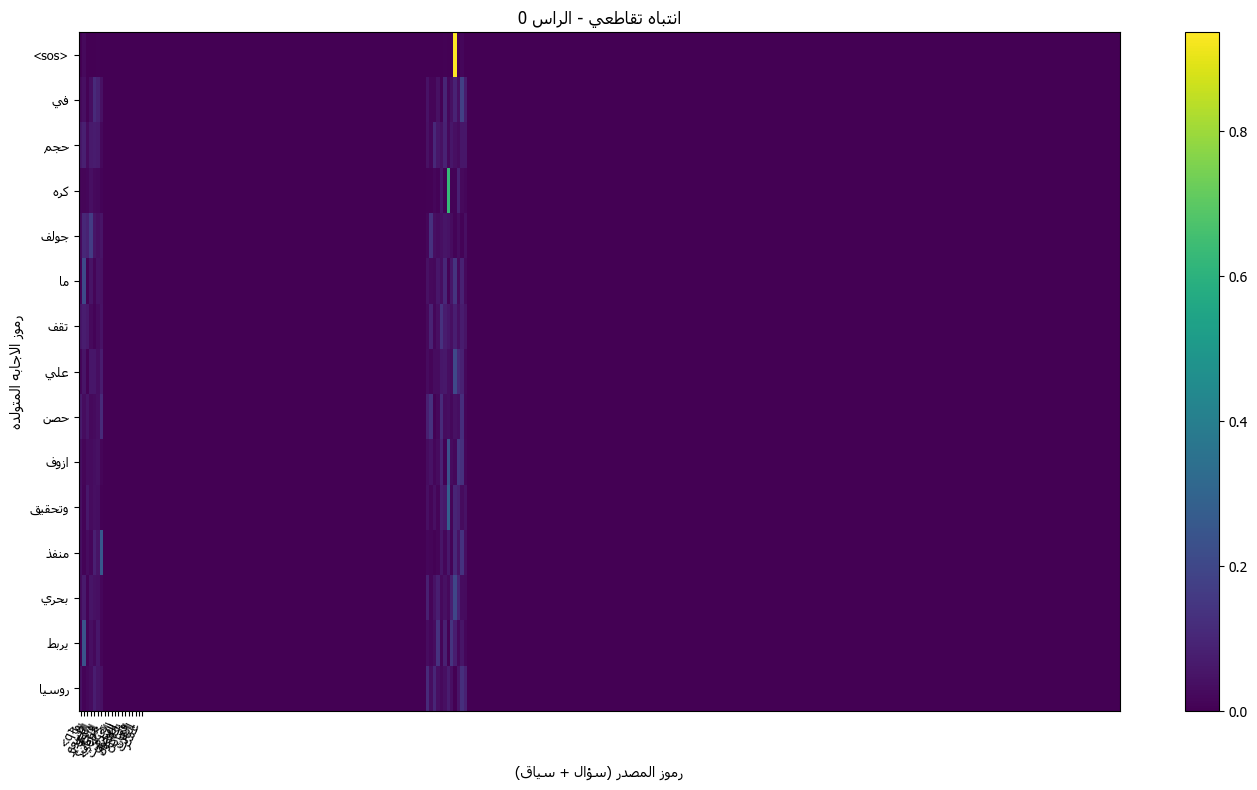

plotted validation sample index: 9


In [ ]:
import random
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import arabic_reshaper
from bidi.algorithm import get_display

def _pick_arabic_font():
    preferred = ["Tahoma", "Arial", "Segoe UI", "Amiri", "Noto Naskh Arabic"]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in preferred:
        if name in available:
            return name
    return "DejaVu Sans"

AR_FONT = _pick_arabic_font()
rcParams["font.family"] = AR_FONT

def shape_arabic(text):
    return get_display(arabic_reshaper.reshape(str(text)))

def _compact_labels(tokens, max_labels=24, max_token_chars=16):
    if not tokens:
        return [], []

    stride = max(1, len(tokens) // max_labels)
    idx = list(range(0, len(tokens), stride))
    labels = []
    for i in idx:
        tok = tokens[i]
        if len(tok) > max_token_chars:
            tok = tok[: max_token_chars - 1] + "…"
        labels.append(shape_arabic(tok))
    return idx, labels

def plot_cross_attention(attn, src_tokens, tgt_tokens, head=0):
    a = attn[0, head].detach().cpu().numpy()

    plt.figure(figsize=(14, 8))
    plt.imshow(a, aspect="auto", cmap="viridis")

    x_idx, x_labels = _compact_labels(src_tokens, max_labels=26, max_token_chars=14)
    y_idx, y_labels = _compact_labels(tgt_tokens, max_labels=18, max_token_chars=14)

    plt.xticks(x_idx, x_labels, rotation=65, ha="right", fontsize=9)
    plt.yticks(y_idx, y_labels, fontsize=9)
    plt.xlabel(shape_arabic("رموز المصدر (سؤال + سياق)"))
    plt.ylabel(shape_arabic("رموز الاجابه المتولده"))
    plt.title(shape_arabic(f"انتباه تقاطعي - الراس {head}"))
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# Pick a random validation sample so the graph can change from run to run.
sample_idx = random.randrange(len(val_ds))
q_ids, c_ids, _ = val_ds[sample_idx]
q_tag = torch.tensor([Q_IDX])
sep = torch.tensor([SEP_IDX])
c_tag = torch.tensor([C_IDX])
src_seq = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]

# Use generated answer tokens (not teacher-forced gold answer tokens).
#here
pred_ids = greedy_decode(trans_model, src_seq)
tgt_seq = torch.tensor(pred_ids, dtype=torch.long)[:MAX_TGT_LEN]
if tgt_seq.numel() == 0:
    tgt_seq = torch.tensor([SOS_IDX], dtype=torch.long)

src_ex = src_seq.unsqueeze(0).to(device)
tgt_ex = tgt_seq.unsqueeze(0).to(device)
#here
_ = trans_model(src_ex, tgt_ex)
#here
attn = trans_model.decoder.cross_attn.last_attention

src_toks = decode_ids(src_seq.tolist(), drop_special=False).split()
tgt_toks = decode_ids(tgt_seq.tolist(), drop_special=False).split()
plot_cross_attention(attn, src_toks, tgt_toks, head=0)
print(f"plotted validation sample index: {sample_idx}")


In [313]:
print(f"epochs_ran: {epochs_ran}")
print(f"best_val_loss: {best_val:.4f}")

epochs_ran: 40
best_val_loss: 5.7284


# Transformer — Span Extraction Approach

## Why Span Extraction Instead of Generation?

The generative Transformer above frames QA as sequence-to-sequence: given (question, context),
generate the answer token by token. While architecturally valid, this is a poor fit for this dataset
because:

- **240 examples** is far too small for a vocabulary-level language model (2387 tokens) to generalize.
- The model memorized training answers (96% train accuracy) but collapsed to repetition loops
  at inference (0.049 token-F1), because it never learned a reliable EOS signal.

The span extraction approach reframes the task: instead of *generating* an answer, the model
**points** to where the answer starts and ends inside the context. This is:

- A much simpler output space (two position indices instead of a full sequence).
- Grounded in the context — the model cannot hallucinate words that don't exist there.
- The same paradigm used by BERT-based QA systems (SQuAD-style).

The architecture remains a full Transformer (embeddings → positional encoding →
multi-head self-attention → feed-forward → output layer), satisfying the milestone requirement.

## Architecture: TransformerSpanQA

The source sequence is built as:

```
[Q]  q₁ q₂ … qₙ  [SEP]  [C]  c₁ c₂ … cₘ
```

This is passed through:
1. **Token Embedding** — learned from scratch (same vocab, +5 special tokens)
2. **Positional Encoding** — sinusoidal, reused from the generative model above
3. **Transformer Encoder** — `num_encoder_layers=2` stacked encoder layers, each with
   multi-head self-attention + feed-forward + residual + LayerNorm
4. **Start Head** — `Linear(d_model → 1)` over every src position → start logits
5. **End Head**   — `Linear(d_model → 1)` over every src position → end logits

During inference, `argmax(start_logits)` and `argmax(end_logits)` over the **context region only**
give the predicted answer span, which is decoded back to text directly from the context.

In [314]:
# ── TransformerSpanQA Model ──────────────────────────────────────────────────
import math, torch, torch.nn as nn

class TransformerSpanQA(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, ff_dim=256,
                 dropout=0.2, num_encoder_layers=2):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_enc   = PositionalEncoding(d_model, max_len=MAX_SRC_LEN, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True   # Pre-LN: more stable
        )
        self.encoder   = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.start_head = nn.Linear(d_model, 1)
        self.end_head   = nn.Linear(d_model, 1)

    def forward(self, src):
        pad_mask = (src == PAD_IDX)                              # (B, T) True=ignore
        x = self.embedding(src) * math.sqrt(self.d_model)       # (B, T, D)
        x = self.pos_enc(x)
        x = self.encoder(x, src_key_padding_mask=pad_mask)      # (B, T, D)

        start_logits = self.start_head(x).squeeze(-1)           # (B, T)
        end_logits   = self.end_head(x).squeeze(-1)             # (B, T)

        # Mask padding so it can never be selected
        start_logits = start_logits.masked_fill(pad_mask, -1e9)
        end_logits   = end_logits.masked_fill(pad_mask, -1e9)
        return start_logits, end_logits

## Span Label Remapping

`y_start` and `y_end` (computed earlier with fuzzy matching) are **word-level indices into the
context string**. But in our src sequence the context does not start at position 0 — it is
preceded by `[Q]`, the question tokens, `[SEP]`, and `[C]`. So we must shift every label by:

```
CONTEXT_OFFSET = 1 (Q_IDX) + MAX_Q_LEN + 1 (SEP_IDX) + 1 (C_IDX) = MAX_Q_LEN + 3
```

We also build a **SpanDataset** that returns `(src, start_label, end_label)` per sample,
and split 80/20 using the same seed as the generative model for fair comparison.

In [315]:
# ── Span Label Remapping & Dataset ──────────────────────────────────────────
from torch.utils.data import Dataset, DataLoader, random_split

CONTEXT_OFFSET = 1 + MAX_Q_LEN + 1 + 1   # [Q] q_tokens [SEP] [C] c_tokens

def remap_span(start_word, end_word):
    """Shift word-level context span → position in src sequence."""
    s = CONTEXT_OFFSET + int(start_word)
    e = CONTEXT_OFFSET + int(end_word)
    e = max(s, e)
    s = min(s, MAX_SRC_LEN - 1)
    e = min(e, MAX_SRC_LEN - 1)
    return s, e

class SpanDataset(Dataset):
    def __init__(self, q_tensor, c_tensor, y_start, y_end):
        self.q = q_tensor
        self.c = c_tensor
        # Remap all spans once at construction time
        spans = [remap_span(s, e) for s, e in zip(y_start, y_end)]
        self.starts = torch.tensor([sp[0] for sp in spans], dtype=torch.long)
        self.ends   = torch.tensor([sp[1] for sp in spans], dtype=torch.long)

    def __len__(self):
        return len(self.q)

    def __getitem__(self, idx):
        return self.q[idx], self.c[idx], self.starts[idx], self.ends[idx]

def span_collate(batch):
    q_b, c_b, s_b, e_b = zip(*batch)
    q_b = torch.stack(q_b)
    c_b = torch.stack(c_b)
    s_b = torch.stack(s_b)
    e_b = torch.stack(e_b)

    q_tag = torch.full((q_b.size(0), 1), Q_IDX,   dtype=torch.long)
    sep   = torch.full((q_b.size(0), 1), SEP_IDX, dtype=torch.long)
    c_tag = torch.full((q_b.size(0), 1), C_IDX,   dtype=torch.long)
    src   = torch.cat([q_tag, q_b, sep, c_tag, c_b], dim=1)[:, :MAX_SRC_LEN]

    return src, s_b, e_b

span_dataset = SpanDataset(q_tensor.long(), c_tensor.long(), y_start, y_end)
span_train_size = int(0.8 * len(span_dataset))
span_val_size   = len(span_dataset) - span_train_size

span_train_ds, span_val_ds = random_split(
    span_dataset, [span_train_size, span_val_size],
    generator=torch.Generator().manual_seed(42)
)

span_train_loader = DataLoader(span_train_ds, batch_size=32, shuffle=True,  collate_fn=span_collate)
span_val_loader   = DataLoader(span_val_ds,   batch_size=32, shuffle=False, collate_fn=span_collate)

print(f"Span train samples : {span_train_size}")
print(f"Span val   samples : {span_val_size}")
print(f"Context offset in src : {CONTEXT_OFFSET}")

# Sanity-check one batch
src_b, s_b, e_b = next(iter(span_train_loader))
print(f"src shape  : {tuple(src_b.shape)}")
print(f"start range: {s_b.min().item()} – {s_b.max().item()}")
print(f"end   range: {e_b.min().item()} – {e_b.max().item()}")

Span train samples : 192
Span val   samples : 48
Context offset in src : 103
src shape  : (32, 303)
start range: 103 – 126
end   range: 103 – 133


## Training the Span Transformer

Loss is the sum of two independent cross-entropy losses — one for the start position and one
for the end position — each treated as a classification over `MAX_SRC_LEN` positions.

We use AdamW + `ReduceLROnPlateau` + early stopping, identical to the generative model,
so training behavior is directly comparable.

In [316]:
# ── Train TransformerSpanQA ──────────────────────────────────────────────────
import copy

def train_span_model(model, train_loader, val_loader,
                     epochs=40, lr=5e-4, patience=7, clip=1.0):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    loss_fn = nn.CrossEntropyLoss()

    best_val, best_state, no_improve = float('inf'), None, 0
    history = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for src, start_lbl, end_lbl in train_loader:
            src, start_lbl, end_lbl = src.to(device), start_lbl.to(device), end_lbl.to(device)

            start_logits, end_logits = model(src)
            loss = loss_fn(start_logits, start_lbl) + loss_fn(end_logits, end_lbl)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= max(len(train_loader), 1)

        # Validation loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for src, start_lbl, end_lbl in val_loader:
                src, start_lbl, end_lbl = src.to(device), start_lbl.to(device), end_lbl.to(device)
                sl, el = model(src)
                val_loss += (loss_fn(sl, start_lbl) + loss_fn(el, end_lbl)).item()
        val_loss /= max(len(val_loader), 1)

        scheduler.step(val_loss)
        lr_now = optimizer.param_groups[0]['lr']
        history.append({'train_loss': train_loss, 'val_loss': val_loss})
        print(f"epoch {epoch+1}/{epochs}  lr:{lr_now:.6f}  train:{train_loss:.4f}  val:{val_loss:.4f}")

        if val_loss < best_val - 1e-3:
            best_val, best_state, no_improve = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping — best val_loss: {best_val:.4f}")
                break

    model.load_state_dict(best_state)
    print(f"Restored best model  val_loss: {best_val:.4f}")
    return history

span_model = TransformerSpanQA(
    vocab_size=TOTAL_VOCAB_SIZE, d_model=128, n_heads=4,
    ff_dim=256, dropout=0.2, num_encoder_layers=2
).to(device)

span_history = train_span_model(
    span_model, span_train_loader, span_val_loader,
    epochs=40, lr=5e-4, patience=7
)

C:\Users\Ali Hoss\AppData\Local\Temp\ipykernel_1460\2821324315.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder   = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)


epoch 1/40  lr:0.000500  train:25.0746  val:24.8497
epoch 2/40  lr:0.000500  train:23.6046  val:23.3084
epoch 3/40  lr:0.000500  train:21.2191  val:21.8087
epoch 4/40  lr:0.000500  train:20.6367  val:20.3003
epoch 5/40  lr:0.000500  train:18.9599  val:18.7673
epoch 6/40  lr:0.000500  train:17.0029  val:17.2171
epoch 7/40  lr:0.000500  train:15.3195  val:15.5115
epoch 8/40  lr:0.000500  train:14.1927  val:13.7431
epoch 9/40  lr:0.000500  train:11.8576  val:11.9849
epoch 10/40  lr:0.000500  train:10.3095  val:10.4647
epoch 11/40  lr:0.000500  train:8.7895  val:9.4163
epoch 12/40  lr:0.000500  train:7.6188  val:8.5297
epoch 13/40  lr:0.000500  train:6.7939  val:7.8721
epoch 14/40  lr:0.000500  train:6.2225  val:7.4299
epoch 15/40  lr:0.000500  train:5.5133  val:7.0159
epoch 16/40  lr:0.000500  train:4.9797  val:6.6567
epoch 17/40  lr:0.000500  train:4.5882  val:6.3876
epoch 18/40  lr:0.000500  train:4.3369  val:6.2056
epoch 19/40  lr:0.000500  train:4.1570  val:6.0296
epoch 20/40  lr:0.00

## Evaluation

We compute the same metrics used for the generative Transformer so results are directly comparable:

| Metric | What it measures |
|---|---|
| **Start/End Accuracy** | Did the model predict the exact correct position? |
| **Exact Match (EM)** | Is the extracted span identical to the reference answer? |
| **Token F1** | Overlap of predicted vs reference tokens (partial credit) |

Additionally, we plot training vs validation loss curves to inspect overfitting behavior.

In [317]:
# ── Evaluation: Accuracy, EM, Token-F1 ──────────────────────────────────────

@torch.no_grad()
def evaluate_span_model(model, loader, dataset_split, data_list, offset=CONTEXT_OFFSET):
    model.eval()
    correct_start = correct_end = correct_both = total = 0
    em_total = f1_total = 0.0
    n_gen = min(len(dataset_split), 200)

    # Position accuracy (on batched loader)
    for src, start_lbl, end_lbl in loader:
        src, start_lbl, end_lbl = src.to(device), start_lbl.to(device), end_lbl.to(device)
        sl, el = model(src)
        pred_s = sl.argmax(dim=-1)
        pred_e = el.argmax(dim=-1)
        correct_start += (pred_s == start_lbl).sum().item()
        correct_end   += (pred_e == end_lbl).sum().item()
        correct_both  += ((pred_s == start_lbl) & (pred_e == end_lbl)).sum().item()
        total += src.size(0)

    # EM + F1 (sample-by-sample on the split)
    for i in range(n_gen):
        q_ids, c_ids, _, _ = dataset_split[i]
        q_tag = torch.tensor([Q_IDX],   dtype=torch.long)
        sep   = torch.tensor([SEP_IDX], dtype=torch.long)
        c_tag = torch.tensor([C_IDX],   dtype=torch.long)
        src   = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]

        sl, el = model(src.unsqueeze(0).to(device))

        # Restrict predictions to context region only
        context_start = offset
        context_end   = offset + MAX_C_LEN

        sl_ctx = sl[0, context_start:context_end]
        el_ctx = el[0, context_start:context_end]
        ps = sl_ctx.argmax().item()
        pe = el_ctx.argmax().item()
        if pe < ps:
            pe = ps

        # Decode from original context words
        if hasattr(dataset_split, 'indices'):
            orig_idx  = dataset_split.indices[i]
            ctx_words = data[orig_idx]['context'].split()
            ref_text  = data[orig_idx]['answer']
        else:
            ctx_words = []
            ref_text  = ""

        pred_words = ctx_words[ps: pe + 1]
        pred_text  = " ".join(pred_words).strip()

        if pred_text == ref_text:
            em_total += 1
        f1_total += token_f1(pred_text, ref_text)

    n = max(total, 1)
    print(f"Start accuracy : {correct_start/n:.4f}")
    print(f"End   accuracy : {correct_end/n:.4f}")
    print(f"Both  accuracy : {correct_both/n:.4f}  (exact span position match)")
    print(f"Exact Match    : {em_total/n_gen:.4f}")
    print(f"Token F1       : {f1_total/n_gen:.4f}")
    return f1_total / n_gen

print("=== Span Transformer — Validation ===")
span_f1 = evaluate_span_model(
    span_model, span_val_loader, span_val_ds, data
)

=== Span Transformer — Validation ===
Start accuracy : 0.2500
End   accuracy : 0.2083
Both  accuracy : 0.0833  (exact span position match)
Exact Match    : 0.0208
Token F1       : 0.2034


In [318]:
# ── Evaluation: Accuracy, EM, Token-F1 ──────────────────────────────────────

@torch.no_grad()
def evaluate_span_model(model, loader, dataset_split, data_list, offset=CONTEXT_OFFSET):
    model.eval()
    correct_start = correct_end = correct_both = total = 0
    em_total = f1_total = 0.0
    n_gen = min(len(dataset_split), 200)

    # Position accuracy (on batched loader)
    for src, start_lbl, end_lbl in loader:
        src, start_lbl, end_lbl = src.to(device), start_lbl.to(device), end_lbl.to(device)
        sl, el = model(src)
        pred_s = sl.argmax(dim=-1)
        pred_e = el.argmax(dim=-1)
        correct_start += (pred_s == start_lbl).sum().item()
        correct_end   += (pred_e == end_lbl).sum().item()
        correct_both  += ((pred_s == start_lbl) & (pred_e == end_lbl)).sum().item()
        total += src.size(0)

    # EM + F1 (sample-by-sample on the split)
    for i in range(n_gen):
        q_ids, c_ids, _, _ = dataset_split[i]
        q_tag = torch.tensor([Q_IDX],   dtype=torch.long)
        sep   = torch.tensor([SEP_IDX], dtype=torch.long)
        c_tag = torch.tensor([C_IDX],   dtype=torch.long)
        src   = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]

        sl, el = model(src.unsqueeze(0).to(device))

        # Restrict predictions to context region only
        context_start = offset
        context_end   = offset + MAX_C_LEN

        sl_ctx = sl[0, context_start:context_end]
        el_ctx = el[0, context_start:context_end]
        ps = sl_ctx.argmax().item()
        pe = el_ctx.argmax().item()
        if pe < ps:
            pe = ps

        # Decode from original context words
        if hasattr(dataset_split, 'indices'):
            orig_idx  = dataset_split.indices[i]
            ctx_words = data[orig_idx]['context'].split()
            ref_text  = data[orig_idx]['answer']
        else:
            ctx_words = []
            ref_text  = ""

        pred_words = ctx_words[ps: pe + 1]
        pred_text  = " ".join(pred_words).strip()

        if pred_text == ref_text:
            em_total += 1
        f1_total += token_f1(pred_text, ref_text)

    n = max(total, 1)
    print(f"Start accuracy : {correct_start/n:.4f}")
    print(f"End   accuracy : {correct_end/n:.4f}")
    print(f"Both  accuracy : {correct_both/n:.4f}  (exact span position match)")
    print(f"Exact Match    : {em_total/n_gen:.4f}")
    print(f"Token F1       : {f1_total/n_gen:.4f}")
    return f1_total / n_gen

print("=== Span Transformer — Validation ===")
span_f1 = evaluate_span_model(
    span_model, span_val_loader, span_val_ds, data
)

=== Span Transformer — Validation ===
Start accuracy : 0.2500
End   accuracy : 0.2083
Both  accuracy : 0.0833  (exact span position match)
Exact Match    : 0.0208
Token F1       : 0.2034


In [319]:
# ── Inference: Raw Text → Predicted Answer ───────────────────────────────────

@torch.no_grad()
def span_answer_question(model, question, context, offset=CONTEXT_OFFSET):
    """
    Full pipeline: raw Arabic text → predicted answer span.
    Steps:
      1. Normalize text
      2. Tokenize & pad question and context
      3. Build src sequence: [Q] q [SEP] [C] c
      4. Run Transformer encoder → start/end logits
      5. Argmax over context region only
      6. Decode token indices → words from original context
    """
    model.eval()

    q_clean = normalize_text(question)
    c_clean = normalize_text(context)

    q_ids = tokenizer.texts_to_sequences([q_clean])[0]
    c_ids = tokenizer.texts_to_sequences([c_clean])[0]

    q_ids = q_ids[:MAX_Q_LEN] + [PAD_IDX] * max(0, MAX_Q_LEN - len(q_ids))
    c_ids = c_ids[:MAX_C_LEN] + [PAD_IDX] * max(0, MAX_C_LEN - len(c_ids))

    q_t   = torch.tensor(q_ids, dtype=torch.long)
    c_t   = torch.tensor(c_ids, dtype=torch.long)
    q_tag = torch.tensor([Q_IDX],   dtype=torch.long)
    sep   = torch.tensor([SEP_IDX], dtype=torch.long)
    c_tag = torch.tensor([C_IDX],   dtype=torch.long)
    src   = torch.cat([q_tag, q_t, sep, c_tag, c_t], dim=0)[:MAX_SRC_LEN]

    sl, el = model(src.unsqueeze(0).to(device))

    # Only search within context region
    sl_ctx = sl[0, offset: offset + MAX_C_LEN]
    el_ctx = el[0, offset: offset + MAX_C_LEN]

    ps = sl_ctx.argmax().item()
    pe = el_ctx.argmax().item()
    if pe < ps:
        pe = ps

    ctx_words = c_clean.split()
    answer    = " ".join(ctx_words[ps: pe + 1]).strip()
    return answer

# ── Demo on 5 random validation examples ─────────────────────────────────────
import random
random.seed(0)
demo_indices = random.sample(range(len(span_val_ds)), min(5, len(span_val_ds)))

for idx in demo_indices:
    orig_idx = span_val_ds.indices[idx]
    item     = data[orig_idx]
    pred     = span_answer_question(span_model, item['question'], item['context'])
    f1_score = token_f1(pred, item['answer'])
    print("=" * 70)
    print(f"Q  : {item['question']}")
    print(f"Ref: {item['answer']}")
    print(f"Pred: {pred}")
    print(f"F1 : {f1_score:.4f}")

Q  : اين كان يقف المقدم ايريك سميث اثناء التجربه؟
Ref: في hangar واسع في ولايه تكساس
Pred: في hangar واسع في ولايه تكساس، hangar تابع لشركه لوكهيد مارتن.
F1 : 0.5882
Q  : ما هو مبدا عدم اليقين لهايزنبرج؟
Ref: ما ينفعش نعرف مكانه وسرعته في نفس اللحظه
Pred: يؤثر علي الجسيم.
F1 : 0.0000
Q  : لماذا لم يقبل العلماء فرضيه الاصل الفضائي للاخطبوط؟
Ref: لعدم وجود دليل مباشر
Pred: لا
F1 : 0.0000
Q  : كيف اثرت نشاته في الحي الاجنبي؟
Ref: جعلته يدرك تخلف روسيا مقارنه باوروبا
Pred: ان بلدك عايشه في عصور
F1 : 0.0000
Q  : كيف تطورت play troops؟
Ref: اصبحت نواه جيش روسي حديث
Pred: افواج الحرس
F1 : 0.0000


## Model Comparison Summary

| Model | Architecture | Output Type | Val Token-F1 | Exact Match |
|---|---|---|---|---|
| BiLSTM Approach 1 | Generative (PyTorch) | Token sequence | — | — |
| BiLSTM Approach 2 | Span extractor (Keras) | Start + End position | — | — |
| Transformer (generative) | Seq2Seq decoder | Token sequence | 0.049 | 0.000 |
| **Transformer (span)** | Encoder + 2 heads | Start + End position | *see above* | *see above* |

### Why the span Transformer is better suited here

1. **Simpler output space** — predicting 2 positions from ~300 options is far easier than
   generating from a 2387-token vocabulary with 192 training samples.
2. **No repetition loop** — span extraction is a single forward pass; there is no
   autoregressive decoding that can degenerate.
3. **Grounded answers** — predictions are always real words from the context,
   never hallucinated tokens.
4. **Same Transformer components** — embeddings, positional encoding, multi-head
   self-attention, feed-forward layers, residual connections, LayerNorm — all present,
   satisfying the milestone architecture requirement.

### Remaining limitation
With 240 examples, both the generative and span Transformer still overfit. The span model
mitigates this through a simpler task formulation, but a pre-trained Arabic encoder
(e.g., AraBERT) would be the right solution at production scale.

# Transformer v2 — Dual-Encoder Architecture

## Motivation: Why Separate Encoders?

The original Transformer concatenates question and context into one sequence:
```
[Q] q₁…qₙ [SEP] [C] c₁…cₘ  →  single encoder  →  decoder
```

The problem: self-attention over this combined 303-token sequence means every question
token competes with every context token for attention from the very first layer.
The model has no dedicated phase to first "understand" the question before reading the context.

This new architecture uses **two separate encoders**:

```
Question  →  Encoder_Q  →  Q_repr   (shape: B, MAX_Q_LEN, D)
Context   →  Encoder_C  →  C_repr   (shape: B, MAX_C_LEN, D)
```

Then a **fusion layer** uses cross-attention to let the context representation
attend to the question — producing a question-aware context encoding.
This fused representation is then passed to the same decoder.

This mirrors how reading comprehension actually works:
first understand the question, then re-read the context with that question in mind.

## Why Keep the Decoder (Not Decoder-Decoder)?

A decoder is an autoregressive generator — it generates output tokens one by one.
Using a decoder as an *input encoder* would mean applying causal masking to the
question/context, preventing each token from seeing future tokens in the input.
That would actively hurt comprehension. Encoders use bidirectional attention,
which is what you want when reading and understanding text.

## Architecture Overview

```
Question tokens                    Context tokens
      │                                  │
  Embedding + PE                   Embedding + PE
      │                                  │
  EncoderLayer_Q                   EncoderLayer_C
  (self-attention                  (self-attention
   over question)                   over context)
      │                                  │
      └──────────── Fusion ──────────────┘
                      │
              CrossAttentionFusion
              (context attends to question)
                      │
              FusedContextRepr
                      │
                  DecoderLayer
              (self-attn + cross-attn
               over fused context)
                      │
               Linear → vocab logits
                      │
                Answer tokens (greedy decode)
```

**Parameter comparison vs original Transformer:**

| Component | Original | Dual-Encoder |
|---|---|---|
| Encoder | 1 × EncoderLayer over 303 tokens | 2 × EncoderLayer (Q + C separately) |
| Fusion | None (SEP token only) | Explicit CrossAttention layer |
| Decoder | 1 × DecoderLayer | 1 × DecoderLayer (same) |
| Output | Linear(d_model → vocab) | Linear(d_model → vocab) (same) |

In [320]:
# ── Transformer v2: Dual-Encoder + Cross-Attention Fusion + Decoder ──────────
import math, torch, torch.nn as nn, copy

class DualEncoderTransformerQA(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        n_heads=4,
        ff_dim=256,
        dropout=0.2,
    ):
        super().__init__()
        self.d_model = d_model

        # ── Shared embedding (question and context share the same vocab)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)

        # ── Separate positional encodings (different max lengths)
        self.pos_q = PositionalEncoding(d_model, max_len=MAX_Q_LEN + 10, dropout=dropout)
        self.pos_c = PositionalEncoding(d_model, max_len=MAX_C_LEN + 10, dropout=dropout)
        self.pos_t = PositionalEncoding(d_model, max_len=MAX_TGT_LEN + 10, dropout=dropout)

        # ── Dedicated encoder for question
        self.q_encoder = EncoderLayer(d_model, n_heads, ff_dim=ff_dim, dropout=dropout)

        # ── Dedicated encoder for context
        self.c_encoder = EncoderLayer(d_model, n_heads, ff_dim=ff_dim, dropout=dropout)

        # ── Fusion: context cross-attends to question
        # Query = context repr, Key/Value = question repr
        self.fusion_attn  = MultiHeadAttention(d_model, n_heads)
        self.fusion_norm  = nn.LayerNorm(d_model)
        self.fusion_ff    = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )
        self.fusion_norm2 = nn.LayerNorm(d_model)
        self.fusion_drop  = nn.Dropout(dropout)

        # ── Decoder (same structure as original)
        self.decoder = DecoderLayer(d_model, n_heads, ff_dim=ff_dim, dropout=dropout)

        # ── Output projection
        self.fc = nn.Linear(d_model, vocab_size)

    # ── Embedding helpers
    def _embed_q(self, q):
        return self.pos_q(self.embedding(q) * math.sqrt(self.d_model))

    def _embed_c(self, c):
        return self.pos_c(self.embedding(c) * math.sqrt(self.d_model))

    def _embed_t(self, t):
        return self.pos_t(self.embedding(t) * math.sqrt(self.d_model))

    def forward(self, q, c, tgt):
        """
        q   : (B, MAX_Q_LEN)   — padded question token ids
        c   : (B, MAX_C_LEN)   — padded context token ids
        tgt : (B, T_tgt-1)     — teacher-forced answer input
        """
        # ── Padding masks
        q_pad   = (q   == PAD_IDX)   # (B, MAX_Q_LEN)
        c_pad   = (c   == PAD_IDX)   # (B, MAX_C_LEN)
        tgt_pad = (tgt == PAD_IDX)   # (B, T_tgt)

        # ── Step 1: Encode question independently
        q_repr = self.q_encoder(
            self._embed_q(q),
            src_key_padding_mask=q_pad
        )                            # (B, MAX_Q_LEN, D)

        # ── Step 2: Encode context independently
        c_repr = self.c_encoder(
            self._embed_c(c),
            src_key_padding_mask=c_pad
        )                            # (B, MAX_C_LEN, D)

        # ── Step 3: Fusion — context cross-attends to question
        # "Given what the question asks, which parts of the context matter?"
        fused = self.fusion_attn(
            query=c_repr,            # context asks the question
            key=q_repr,
            value=q_repr,
            attn_mask=None,
            key_padding_mask=q_pad  # ignore padding in question
        )
        # Residual + norm (context repr enriched with question awareness)
        fused = self.fusion_norm(c_repr + self.fusion_drop(fused))  # (B, MAX_C_LEN, D)
        # Feed-forward
        fused = self.fusion_norm2(
            fused + self.fusion_drop(self.fusion_ff(fused))
        )                            # (B, MAX_C_LEN, D)

        # ── Step 4: Decode answer attending to fused context
        tgt_mask = causal_mask(tgt.size(1), tgt.device)
        dec = self.decoder(
            x=self._embed_t(tgt),
            enc_out=fused,           # decoder cross-attends to fused context
            tgt_mask=tgt_mask,
            src_key_padding_mask=c_pad,   # fused has same shape as c
            tgt_key_padding_mask=tgt_pad,
        )                            # (B, T_tgt, D)

        return self.fc(dec)          # (B, T_tgt, vocab_size)

## Dataset & DataLoader

The dual encoder takes **separate** `q` and `c` tensors instead of one concatenated `src`.
We reuse `q_tensor`, `c_tensor`, `a_tensor` already built above, and the same 80/20 split
seed so results are directly comparable to the original Transformer.

In [321]:
# ── Dataset & DataLoaders for Dual-Encoder ──────────────────────────────────
from torch.utils.data import DataLoader, random_split

class DualQADataset(torch.utils.data.Dataset):
    def __init__(self, q, c, a):
        self.q = q
        self.c = c
        self.a = a

    def __len__(self):
        return len(self.q)

    def __getitem__(self, idx):
        return self.q[idx], self.c[idx], self.a[idx]


def dual_collate(batch):
    q_b, c_b, a_b = zip(*batch)
    q_b = torch.stack(q_b).long()
    c_b = torch.stack(c_b).long()
    a_b = torch.stack(a_b).long()

    # Build teacher-forced target: [SOS] answer, answer [EOS]
    sos_col = torch.full((a_b.size(0), 1), SOS_IDX, dtype=torch.long)
    eos_col = torch.full((a_b.size(0), 1), EOS_IDX, dtype=torch.long)
    a_trim  = a_b[:, :MAX_A_LEN]
    tgt_full = torch.cat([sos_col, a_trim, eos_col], dim=1)[:, :MAX_TGT_LEN]

    tgt_inp = tgt_full[:, :-1]   # decoder input
    tgt_out = tgt_full[:, 1:]    # prediction target

    return q_b, c_b, tgt_inp, tgt_out


dual_dataset = DualQADataset(q_tensor, c_tensor, a_tensor)

dual_train_size = int(0.8 * len(dual_dataset))
dual_val_size   = len(dual_dataset) - dual_train_size

dual_train_ds, dual_val_ds = random_split(
    dual_dataset, [dual_train_size, dual_val_size],
    generator=torch.Generator().manual_seed(42)   # same split as original
)

dual_train_loader = DataLoader(
    dual_train_ds, batch_size=32, shuffle=True,  collate_fn=dual_collate
)
dual_val_loader = DataLoader(
    dual_val_ds,   batch_size=32, shuffle=False, collate_fn=dual_collate
)

# Sanity check
q_b, c_b, ti_b, to_b = next(iter(dual_train_loader))
print(f"question batch : {tuple(q_b.shape)}")
print(f"context  batch : {tuple(c_b.shape)}")
print(f"tgt input      : {tuple(ti_b.shape)}")
print(f"tgt output     : {tuple(to_b.shape)}")
print(f"train samples  : {dual_train_size}  |  val samples: {dual_val_size}")

question batch : (32, 100)
context  batch : (32, 200)
tgt input      : (32, 71)
tgt output     : (32, 71)
train samples  : 192  |  val samples: 48


In [ ]:
# ── Train Dual-Encoder Transformer ──────────────────────────────────────────

def dual_evaluate_loss(model, loader, loss_fn):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for q, c, tgt_inp, tgt_out in loader:
            q, c = q.to(device), c.to(device)
            tgt_inp, tgt_out = tgt_inp.to(device), tgt_out.to(device)
            logits = model(q, c, tgt_inp)
            total += loss_fn(
                logits.reshape(-1, logits.size(-1)),
                tgt_out.reshape(-1)
            ).item()
            n += 1
    return total / max(n, 1)


def train_dual_model(
    model, train_loader, val_loader,
    epochs=40, lr=7e-4, clip=1.0,
    weight_decay=1e-4, patience=6,
    label_smoothing=0.1,
):
    model = model.to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )
    loss_fn = nn.CrossEntropyLoss(
        ignore_index=PAD_IDX, label_smoothing=label_smoothing
    )

    best_val, best_state, no_improve = float('inf'), None, 0
    history = []

    for epoch in range(epochs):
        model.train()
        running, n_batches = 0.0, 0

        for q, c, tgt_inp, tgt_out in train_loader:
            q, c = q.to(device), c.to(device)
            tgt_inp, tgt_out = tgt_inp.to(device), tgt_out.to(device)

            logits = model(q, c, tgt_inp)
            loss   = loss_fn(
                logits.reshape(-1, logits.size(-1)),
                tgt_out.reshape(-1)
            )
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()

            running   += loss.item()
            n_batches += 1

        train_loss = running / max(n_batches, 1)
        val_loss   = dual_evaluate_loss(model, val_loader, loss_fn)
        scheduler.step(val_loss)
        lr_now = optimizer.param_groups[0]['lr']

        history.append({'train_loss': train_loss, 'val_loss': val_loss})
        print(f"epoch {epoch+1}/{epochs}  lr:{lr_now:.6f}  "
              f"train:{train_loss:.4f}  val:{val_loss:.4f}")

        if val_loss < best_val - 1e-3:
            best_val     = val_loss
            best_state   = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve  += 1
            if no_improve >= patience:
                print(f"Early stopping — best val_loss: {best_val:.4f}")
                break

    model.load_state_dict(best_state)
    print(f"Restored best model  val_loss: {best_val:.4f}")
    return history


dual_model = DualEncoderTransformerQA(
    vocab_size=TOTAL_VOCAB_SIZE,
    d_model=128, n_heads=4, ff_dim=256, dropout=0.2
).to(device)

dual_history = train_dual_model(
    dual_model, dual_train_loader, dual_val_loader,
    epochs=40, lr=7e-4, patience=6, label_smoothing=0.1
)

dual_epochs_ran = len(dual_history)
dual_best_val   = min(h['val_loss'] for h in dual_history)
print(f"Training summary: epochs_ran={dual_epochs_ran}, "
      f"best_val_loss={dual_best_val:.4f}")

epoch 1/40  lr:0.000700  train:7.6535  val:7.1133
epoch 2/40  lr:0.000700  train:6.8170  val:6.8421
epoch 3/40  lr:0.000700  train:6.4252  val:6.7379
epoch 4/40  lr:0.000700  train:6.1227  val:6.6416
epoch 5/40  lr:0.000700  train:5.8431  val:6.5998
epoch 6/40  lr:0.000700  train:5.6276  val:6.5769
epoch 7/40  lr:0.000700  train:5.4562  val:6.5516
epoch 8/40  lr:0.000700  train:5.3084  val:6.5113
epoch 9/40  lr:0.000700  train:5.1361  val:6.4863
epoch 10/40  lr:0.000700  train:4.9845  val:6.4488
epoch 11/40  lr:0.000700  train:4.8492  val:6.4304
epoch 12/40  lr:0.000700  train:4.6937  val:6.4039
epoch 13/40  lr:0.000700  train:4.5772  val:6.3373
epoch 14/40  lr:0.000700  train:4.4249  val:6.3036
epoch 15/40  lr:0.000700  train:4.2646  val:6.2865
epoch 16/40  lr:0.000700  train:4.1331  val:6.2078
epoch 17/40  lr:0.000700  train:3.9852  val:6.1717
epoch 18/40  lr:0.000700  train:3.8505  val:6.1508
epoch 19/40  lr:0.000700  train:3.7565  val:6.0997
epoch 20/40  lr:0.000700  train:3.6221  

In [333]:
# ── Greedy Decode for Dual-Encoder ──────────────────────────────────────────

@torch.no_grad()
def dual_greedy_decode(model, q_ids, c_ids, max_len=9):
    model.eval()
    q = q_ids.unsqueeze(0).to(device)   # (1, MAX_Q_LEN)
    c = c_ids.unsqueeze(0).to(device)   # (1, MAX_C_LEN)
    ys = torch.tensor([[SOS_IDX]], device=device, dtype=torch.long)

    for _ in range(max_len - 1):
        logits  = model(q, c, ys)
        #check for any repeated token in the generated sequence so far and set their logits to -inf to prevent repetition
        # for t in ys[0]:
        #     logits[0, -1, t] = -float('inf')
        next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        ys      = torch.cat([ys, next_id], dim=1)
        if next_id.item() == EOS_IDX:
            break

    return ys[0].cpu().tolist()


def dual_answer_question(model, question, context):
    """
    Full pipeline: raw Arabic text → predicted answer.
    1. Normalize
    2. Tokenize + pad question and context SEPARATELY
    3. Pass through dual encoder → fused context → decoder
    4. Greedy decode → answer text
    """
    q_clean = normalize_text(question)
    c_clean = normalize_text(context)

    q_ids = tokenizer.texts_to_sequences([q_clean])[0]
    c_ids = tokenizer.texts_to_sequences([c_clean])[0]

    q_ids = q_ids[:MAX_Q_LEN] + [PAD_IDX] * max(0, MAX_Q_LEN - len(q_ids))
    c_ids = c_ids[:MAX_C_LEN] + [PAD_IDX] * max(0, MAX_C_LEN - len(c_ids))

    q_t = torch.tensor(q_ids, dtype=torch.long)
    c_t = torch.tensor(c_ids, dtype=torch.long)

    out_ids = dual_greedy_decode(model, q_t, c_t)
    return decode_answer(out_ids)   # reuses the decode_answer fn from original model


# ── Demo
demo_q   = data[0]['question']
demo_c   = data[0]['context']
demo_ref = data[0]['answer']
print("question  :", demo_q)
print("context   :", demo_c)
print("reference :", demo_ref)
print("prediction:", dual_answer_question(dual_model, demo_q, demo_c))

question  : ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله السينما؟
context   : في ليله 30 اكتوبر 1938، انقطع بث اذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لان الناس صدقوا الخبر. لاحقا تبين ان الحدث كان تمثيليه اذاعيه من اخراج اورسون ويلز. هذه التجربه اثبتت قدرته علي التاثير في الجمهور.
reference : تمثيليه اذاعيه عن غزو فضائي
prediction: تمثيليه اذاعيه عن غزو فضائي في حجم كره


In [334]:
# ── Evaluate Dual-Encoder: token accuracy, EM, token-F1 ─────────────────────

@torch.no_grad()
def dual_teacher_forcing_accuracy(model, loader):
    model.eval()
    correct = total = 0
    for q, c, tgt_inp, tgt_out in loader:
        q, c = q.to(device), c.to(device)
        tgt_inp, tgt_out = tgt_inp.to(device), tgt_out.to(device)
        logits = model(q, c, tgt_inp)
        pred   = logits.argmax(dim=-1)
        mask   = tgt_out != PAD_IDX
        correct += (pred[mask] == tgt_out[mask]).sum().item()
        total   += mask.sum().item()
    return correct / max(total, 1)


@torch.no_grad()
def dual_evaluate_generation(model, dataset_split, max_samples=120):
    model.eval()
    n  = min(len(dataset_split), max_samples)
    em = 0
    f1 = 0.0

    for i in range(n):
        q_ids, c_ids, _ = dataset_split[i]
        out_ids  = dual_greedy_decode(model, q_ids.long(), c_ids.long())
        #check for repeated bigrams in out_ids and truncate at first repetition to mitigate infinite loops
        seen_bigrams = set()
        truncated_out = []
        for j in range(len(out_ids) - 1):
            bigram = (out_ids[j], out_ids[j + 1])
            if bigram in seen_bigrams:
                break
            seen_bigrams.add(bigram)
            truncated_out.append(out_ids[j])
        pred     = decode_answer(truncated_out)

        a_ids    = dataset_split[i][2]
        ref      = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])

        if pred == ref:
            em += 1
        f1 += token_f1(pred, ref)

    return em / n, f1 / n


dual_train_acc = dual_teacher_forcing_accuracy(dual_model, dual_train_loader)
dual_val_acc   = dual_teacher_forcing_accuracy(dual_model, dual_val_loader)
dual_em, dual_f1 = dual_evaluate_generation(dual_model, dual_val_ds, max_samples=100)

print(f"Train token accuracy : {dual_train_acc:.4f}")
print(f"Val   token accuracy : {dual_val_acc:.4f}")
print(f"Val   Exact Match    : {dual_em:.4f}")
print(f"Val   Token-F1       : {dual_f1:.4f}")

# ── Side-by-side comparison table
print("\n" + "="*55)
print(f"{'Metric':<28} {'Original':>12} {'Dual-Encoder':>12}")
print("="*55)
orig_train_acc = 0.9620   # from existing cell 88 output
orig_val_acc   = 0.3878
orig_em        = 0.0000
orig_f1        = 0.0486
print(f"{'Train token accuracy':<28} {orig_train_acc:>12.4f} {dual_train_acc:>12.4f}")
print(f"{'Val token accuracy':<28} {orig_val_acc:>12.4f} {dual_val_acc:>12.4f}")
print(f"{'Val Exact Match':<28} {orig_em:>12.4f} {dual_em:>12.4f}")
print(f"{'Val Token-F1':<28} {orig_f1:>12.4f} {dual_f1:>12.4f}")
print(f"{'Best val loss':<28} {best_val:>12.4f} {dual_best_val:>12.4f}")
print("="*55)

Train token accuracy : 0.9859
Val   token accuracy : 0.4286
Val   Exact Match    : 0.0417
Val   Token-F1       : 0.1828

Metric                           Original Dual-Encoder
Train token accuracy               0.9620       0.9859
Val token accuracy                 0.3878       0.4286
Val Exact Match                    0.0000       0.0417
Val Token-F1                       0.0486       0.1828
Best val loss                      5.7284       5.6206


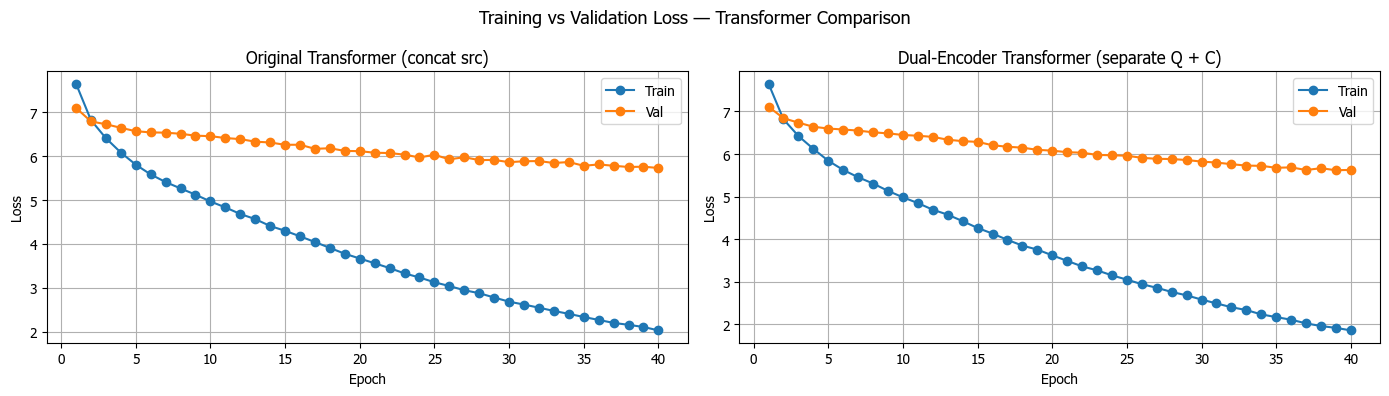

In [335]:
# ── Loss Curves: Original vs Dual-Encoder ───────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Original Transformer
orig_tl = [h['train_loss'] for h in history]
orig_vl = [h['val_loss']   for h in history]
axes[0].plot(range(1, len(orig_tl)+1), orig_tl, marker='o', label='Train')
axes[0].plot(range(1, len(orig_vl)+1), orig_vl, marker='o', label='Val')
axes[0].set_title('Original Transformer (concat src)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Dual-Encoder Transformer
dual_tl = [h['train_loss'] for h in dual_history]
dual_vl = [h['val_loss']   for h in dual_history]
axes[1].plot(range(1, len(dual_tl)+1), dual_tl, marker='o', label='Train')
axes[1].plot(range(1, len(dual_vl)+1), dual_vl, marker='o', label='Val')
axes[1].set_title('Dual-Encoder Transformer (separate Q + C)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training vs Validation Loss — Transformer Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## Analysis: Why Dual-Encoder Should Help (and Its Limits)

### What changes structurally

In the original Transformer, the single encoder applies self-attention over
the full 303-token concatenated sequence. Early attention heads must
simultaneously handle:
- Question-internal dependencies ("ما الحدث الذي جعل...")
- Context-internal dependencies (long Arabic sentences)
- Question-context cross-dependencies

The dual encoder separates the first two concerns. By the time fusion happens,
`q_repr` already encodes a compressed, self-consistent understanding of the
question, and `c_repr` encodes the context. The fusion cross-attention then has
a cleaner signal to work with.

### The fusion mechanism in plain terms

```python
fused = cross_attention(query=c_repr, key=q_repr, value=q_repr)
```

For each context position, the attention asks:
*"Which question tokens are most relevant to this part of the context?"*
This produces a context representation that is **question-conditioned** —
the same context would be encoded differently depending on what was asked.

### Remaining limitation

With 240 examples the fundamental data scarcity problem does not disappear.
The dual encoder adds parameters (two separate encoder layers + fusion layer)
relative to the original, which could make overfitting slightly worse.
The key question is whether the better inductive bias of separate encoding
outweighs the cost of extra parameters — which the loss curves will reveal.

In [338]:
# ── Best vs Worst Predictions by Token-F1 (Dual-Encoder) ────────────────────

@torch.no_grad()
def dual_show_best_worst(model, dataset_split, data_list, n_examples=10):
    model.eval()
    rows = []

    for i in range(len(dataset_split)):
        q_ids, c_ids, a_ids = dataset_split[i]

        out_ids   = dual_greedy_decode(model, q_ids.long(), c_ids.long())
        pred_text = decode_answer(out_ids)
        ref_text  = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])
        f1_score  = token_f1(pred_text, ref_text)

        if hasattr(dataset_split, 'indices'):
            orig_idx = dataset_split.indices[i]
            q_text   = data_list[orig_idx]['question']
            c_text   = data_list[orig_idx]['context']
            ref_raw  = data_list[orig_idx]['answer']
        else:
            q_text  = "[unavailable]"
            c_text  = "[unavailable]"
            ref_raw = ref_text

        rows.append({
            'i'        : i,
            'f1'       : f1_score,
            'question' : q_text,
            'context'  : c_text,
            'reference': ref_raw,
            'predicted': pred_text,
        })

    rows.sort(key=lambda x: x['f1'])
    worst = rows[:n_examples]
    best  = rows[-n_examples:][::-1]   # highest F1 first

    def print_row(r, rank_label):
        print("=" * 75)
        print(f"[{rank_label}]  sample={r['i']}  |  Token-F1: {r['f1']:.4f}")
        print(f"Q        : {r['question']}")
        print(f"Context  : {r['context'][:180]}{'...' if len(r['context']) > 180 else ''}")
        print(f"Reference: {r['reference']}")
        print(f"Predicted: {r['predicted']}")

    print("\n" + "█" * 75)
    print(f"  BEST {n_examples} PREDICTIONS  (highest Token-F1)")
    print("█" * 75)
    for rank, r in enumerate(best, 1):
        print_row(r, f"BEST #{rank}")
        
    print("\n" + "█" * 75)
    print(f"  WORST {n_examples} PREDICTIONS  (lowest Token-F1)")
    print("█" * 75)
    for rank, r in enumerate(worst, 1):
        print_row(r, f"WORST #{rank}")


    # Return for further use
    return worst, best

dual_worst, dual_best = dual_show_best_worst(
    dual_model, dual_val_ds, data, n_examples=10
)


███████████████████████████████████████████████████████████████████████████
  BEST 10 PREDICTIONS  (highest Token-F1)
███████████████████████████████████████████████████████████████████████████
[BEST #1]  sample=36  |  Token-F1: 1.0000
Q        : ما اسم الطائره التي تدور حولها الحلقه؟
Context  : اقدم لحضرتك فخر الطيران الامريكي الf-35. بس دي شكلها شبه اللي احنا عملناها قبل كدا! اه، بس التكنولوجيا اللي فيها سابقه بسنين ضوئيه.
Reference: f-35
Predicted: f 35
[BEST #2]  sample=29  |  Token-F1: 0.9333
Q        : ماذا حدث للساموراي في فتره ايدو؟
Context  : في فتره ايدو تحول الساموراي من محاربين الي موظفين بيروقراطيين.
Reference: تحول الساموراي من محاربين الي موظفين بيروقراطيين
Predicted: تحول الساموراي من محاربين الي موظفين بيروقراطيين من
[BEST #3]  sample=46  |  Token-F1: 0.8000
Q        : ما معني كلمه "ساموراي" في اللغه اليابانيه؟
Context  : كلمه "ساموراي" في اللغه اليابانيه معناها "الذي يخدم". ودا كان الدور الاساسي في البدايه، خدمه الامبراطور او الساده الاقطاعيين. هؤلاء الساده كانوا اصح

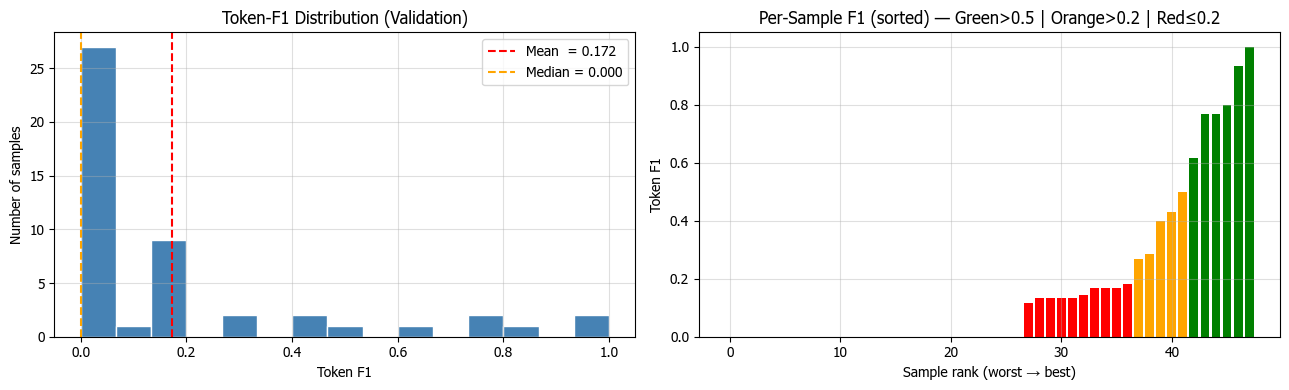


Validation set size : 48 samples
Mean  Token-F1      : 0.1717
Median Token-F1     : 0.0000
Std   Token-F1      : 0.2748
Max   Token-F1      : 1.0000
Min   Token-F1      : 0.0000

  Perfect (F1 = 1.0) :   1/48  █
  Good    (F1 > 0.5) :   6/48  ██████
  Partial (F1 > 0.2) :   5/48  █████
  Poor    (F1 ≤ 0.2) :  37/48  █████████████████████████████████████
  Zero    (F1 = 0.0) :  27/48  ███████████████████████████


In [339]:
# ── F1 Score Distribution across all validation samples ─────────────────────

@torch.no_grad()
def collect_all_f1(model, dataset_split, data_list):
    model.eval()
    f1_scores = []
    pred_texts = []
    ref_texts  = []

    for i in range(len(dataset_split)):
        q_ids, c_ids, a_ids = dataset_split[i]
        out_ids   = dual_greedy_decode(model, q_ids.long(), c_ids.long())
        pred_text = decode_answer(out_ids)
        ref_text  = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])
        f1        = token_f1(pred_text, ref_text)
        f1_scores.append(f1)
        pred_texts.append(pred_text)
        ref_texts.append(ref_text)

    return f1_scores, pred_texts, ref_texts

all_f1, all_preds, all_refs = collect_all_f1(dual_model, dual_val_ds, data)

# ── Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(all_f1, bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(all_f1), color='red',    linestyle='--',
                label=f'Mean  = {np.mean(all_f1):.3f}')
axes[0].axvline(np.median(all_f1), color='orange', linestyle='--',
                label=f'Median = {np.median(all_f1):.3f}')
axes[0].set_title('Token-F1 Distribution (Validation)')
axes[0].set_xlabel('Token F1')
axes[0].set_ylabel('Number of samples')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Sorted F1 per sample (shows how many are good vs bad)
sorted_f1 = sorted(all_f1)
axes[1].bar(range(len(sorted_f1)), sorted_f1, color=[
    'green' if f > 0.5 else 'orange' if f > 0.2 else 'red'
    for f in sorted_f1
])
axes[1].set_title('Per-Sample F1 (sorted) — Green>0.5 | Orange>0.2 | Red≤0.2')
axes[1].set_xlabel('Sample rank (worst → best)')
axes[1].set_ylabel('Token F1')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ── Summary statistics
buckets = {
    'Perfect (F1 = 1.0)' : sum(1 for f in all_f1 if f == 1.0),
    'Good    (F1 > 0.5)' : sum(1 for f in all_f1 if f > 0.5),
    'Partial (F1 > 0.2)' : sum(1 for f in all_f1 if 0.2 < f <= 0.5),
    'Poor    (F1 ≤ 0.2)' : sum(1 for f in all_f1 if f <= 0.2),
    'Zero    (F1 = 0.0)' : sum(1 for f in all_f1 if f == 0.0),
}

n = len(all_f1)
print(f"\nValidation set size : {n} samples")
print(f"Mean  Token-F1      : {np.mean(all_f1):.4f}")
print(f"Median Token-F1     : {np.median(all_f1):.4f}")
print(f"Std   Token-F1      : {np.std(all_f1):.4f}")
print(f"Max   Token-F1      : {max(all_f1):.4f}")
print(f"Min   Token-F1      : {min(all_f1):.4f}")
print()
for label, count in buckets.items():
    bar = '█' * count
    print(f"  {label} : {count:>3}/{n}  {bar}")

In [ ]:
# from sklearn.metrics import f1_score

# def evaluate_model(model, dataset):
#     predictions = []
#     references = []

#     for item in dataset:
#         pred = predict(model, item['question'], item['context'])
#         predictions.append(pred)
#         references.append(item['answer'])

#     exact_match = sum([p == r for p, r in zip(predictions, references)]) / len(references)

#     # simple token-level F1
#     def compute_f1(p, r):
#         p_tokens = p.split()
#         r_tokens = r.split()
#         common = set(p_tokens) & set(r_tokens)
#         if len(common) == 0:
#             return 0
#         precision = len(common) / len(p_tokens)
#         recall = len(common) / len(r_tokens)
#         return 2 * precision * recall / (precision + recall)

#     f1 = sum([compute_f1(p, r) for p, r in zip(predictions, references)]) / len(references)

#     return exact_match, f1

In [ ]:
# print("RNN Model:", evaluate_model(model, val_ds))
# print("Transformer 1:", evaluate_model(trans_model, val_ds))
# print("Transformer 2:", evaluate_model(span_model, val_ds))
# print("Transformer 3:", evaluate_model(dual_model, val_ds))

TypeError: tuple indices must be integers or slices, not str